EN ESTE NOTEBOOK:

- Categorizamos los scores.
- Creamos un nuevo dataset (df) en el que se han cambiado los errores y se han reagrupado las categóricas, e imputamos. (este dataset tiene que tener los valores brutos en los biomarcadores).
- Vemos cuál es la combinación de variables numéricas que maximiza el silhoutte score para k = 2, 3, 4, 5. (para esto hay que normalizar primero con StandardScaler).
- Para las tres mejores combinaciones, describimos estos grupos teniendo en cuenta vairables del embarazo, variables de eco y scores en formato categorías. (hay que incluir la media y la desviación para numéricas)
- Usamos las variables numéricas y las categóricas nuevas (las reagrupadas) para hacer clústering y ver la mejor combinación de variables que maximiza el silhouette score.
- Para las tres mejores combinaciones, describimos estos grupos teniendo en cuenta vairables del embarazo, variables de eco y scores en formato categorías. (hay que incluir la media y la desviación para numéricas y % para categóricas)

ADICIONALMENTE HACEMOS:
- Revisamos las variables musculo, grasa, etc que se habían tratado como categóricas
- Revisamos los missings en las variables que aparecen como nan.

Comparación de 2 grupos
- Prueba de normalidad. Hay normalidad si con shapiro da p < 0.05, |skewness| < 1 y |curtosis| <3.
- Para las variables numéricas con distribución normal, usamos prueba T para muestras independientes. Aquí habría que ver si las varianzas son homogéneas, con la prueba de Levene.
- Para las variables numéricas con distribución no normal usamos la prueba de U Mann-Whitney.
El resultado de lo anterior lo ponemos en formato: media +/- desviación estándar (para las que tengan distribución normal) y mediana +/- IQR para las variables con distribución no normal. 
- Para las variables categóricas ponemos el resultado en formato n (%) y usamos el Test de Fisher para variables de 2 categorías, y el chi square para variables con más categorías.

Comparación de > 2 grupos
- Para la normalidad. Hay normalidad si con shapiro da p < 0.05, |skewness| < 1 y |curtosis| <3.
- Para las vriables numéricas con distribución normal con varianzas homogéneas: ANOVA clásico y post-hoc con Tukey
- Para variables numéricas con distribución normal sin varianzas homogéneas: Welch ANOVA y post-hoc con Games-Howell
- Para variables numéricas con distribución no normal: Kruskal–Wallis y post-hoc con Dunn
- Para las variables categóricas ponemos el resultado en formato n (%) y usamos chi square.

In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler

# Categorización de scores

In [2]:
df_cat = pd.read_excel('variables_CARDIOMOM.xlsx')

scl_mapping = {
    'Nada': 0, 'Muy poco': 1, 'Poco': 2, 'Bastante': 3, 'Mucho': 4
}

# Funciones de categorización

def cat_regicor_dieta(score):
    if pd.isna(score): return np.nan
    if score < 23: return "Baja adherencia"
    elif 23 <= score <= 29: return "Adherencia moderada"
    else: return "Alta adherencia"

def cat_regicor_actividad(met):
    if pd.isna(met): return np.nan
    if met < 500: return "Actividad física baja"
    elif 500 <= met <= 1000: return "Actividad física moderada"
    else: return "Actividad física alta"

def cat_pss14(score):
    if pd.isna(score): return np.nan
    if score <= 13: return "Nivel de estrés bajo"
    elif 14 <= score <= 26: return "Nivel de estrés moderado"
    elif 27 <= score <= 40: return "Nivel de estrés alto"
    else: return "Nivel de estrés muy alto"

def cat_mfe30(score):
    if pd.isna(score): return np.nan
    if score < 8: return "Rendimiento de memoria óptimo"
    elif 9 <= score <= 35: return "Función normal (lapsus leves)"
    elif 36 <= score <= 50: return "Deterioro leve"
    else: return "Disfunción moderada-grave"

def cat_scl90r(t_score):
    if pd.isna(t_score): return np.nan
    if t_score >= 80: return "Patología severa"
    elif t_score >= 65: return "EN RIESGO"
    else: return "Normal / Sin riesgo"


df_cat['Cat_Dieta'] = df_cat['Score total'].apply(cat_regicor_dieta)
df_cat['Cat_Actividad'] = df_cat['Act física TOTAL (MET/semana)'].apply(cat_regicor_actividad)
df_cat['Cat_Estres'] = df_cat['Score'].apply(cat_pss14)
df_cat['Cat_Memoria'] = df_cat['Score.1'].apply(cat_mfe30)

# Procesamiento SCL-90-R
scl_items_cols = df_cat.loc[:, "Dolores de cabeza":"Pensar que en mi cabeza hay algo que no funciona bien"].columns
df_scl_numeric = df_cat[scl_items_cols].replace(scl_mapping).apply(pd.to_numeric, errors='coerce')
df_cat['SCL90_IGS_Raw'] = df_scl_numeric.mean(axis=1)

def calcular_t_score(row):
    raw = row['SCL90_IGS_Raw']
    if pd.isna(raw): return np.nan
    # Baremo Mujer (Media 0.17, DT 0.11) basado en el PDF
    return 50 + 10 * ((raw - 0.17) / 0.11)

df_cat['SCL90_T_Score'] = df_cat.apply(calcular_t_score, axis=1)
df_cat['Cat_SCL90R'] = df_cat['SCL90_T_Score'].apply(cat_scl90r)


cols_to_show = ['ID', 'Cat_Dieta', 'Cat_Actividad', 'Cat_Estres', 'Cat_Memoria', 'Cat_SCL90R']

print(df_cat[cols_to_show].head(20).to_string(index=False))

 ID           Cat_Dieta             Cat_Actividad               Cat_Estres                   Cat_Memoria          Cat_SCL90R
  1 Adherencia moderada     Actividad física alta     Nivel de estrés alto Función normal (lapsus leves)    Patología severa
  2 Adherencia moderada     Actividad física alta Nivel de estrés moderado Rendimiento de memoria óptimo    Patología severa
  3     Baja adherencia     Actividad física alta Nivel de estrés moderado                           NaN                 NaN
  4 Adherencia moderada                       NaN Nivel de estrés moderado                Deterioro leve    Patología severa
  5 Adherencia moderada                       NaN     Nivel de estrés alto Función normal (lapsus leves)    Patología severa
  6     Baja adherencia     Actividad física alta     Nivel de estrés alto                           NaN                 NaN
  7     Baja adherencia     Actividad física alta Nivel de estrés moderado                           NaN                 NaN


/var/folders/h2/lk1h3scx0p3cs7sk_k_sxylh0000gn/T/ipykernel_20047/2332308803.py:42: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_cat['Cat_Dieta'] = df_cat['Score total'].apply(cat_regicor_dieta)
/var/folders/h2/lk1h3scx0p3cs7sk_k_sxylh0000gn/T/ipykernel_20047/2332308803.py:43: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_cat['Cat_Actividad'] = df_cat['Act física TOTAL (MET/semana)'].apply(cat_regicor_actividad)
/var/folders/h2/lk1h3scx0p3cs7sk_k_sxylh0000gn/T/ipykernel_20047/2332308803.py:44: PerformanceWarning: DataFrame

# Nuevo dataset + imputación
Con errores corregidos y categóricas agrupadas

In [3]:
# Usamos 'datos_embarazo.csv' porque es el último csv que creamos antes de la primera imputación. Tiene todo el preprocesamiento al completo
df = pd.read_csv('datos_embarazo.csv')

In [4]:
df.shape

(459, 91)

In [5]:
df.columns[1:50]

Index(['id', 'fecha_firma_ci_cardiomom', 'fecha_firma_ci_muestbio',
       'fecha_nac', 'peso_ini_gest', 'peso_fin_gest', 'aumento_peso_gest',
       'talla', 'imc_ini_gest', 'nivel_estudios', 'parto_previo_mayor37_pre',
       'parto_previo_menor37_pre', 'aborto_menor20', 'ant_cir', 'ant_peg',
       'ant_obito', 'ant_pe', 'ant_hellp', 'ant_cesarea',
       'ant_diabetes_pregest', 'hta_pregest', 'sindr_antifosfolipido',
       'enf_autoinm', 'fuma', 'alcohol', 'drogas', 'fur_pre',
       'edad_materna_gest', 'tas_1tri', 'tad_1tri', 'fecha_eco_1tri',
       'eg_eco_1tri', 'uterinas_p95_1tri', 'plgf_1tri', 'riesgo_pe_1tri',
       'uterinas_p95_eco_2tri', 'deter_sflt1_plgf_gest', 'fecha_ult_deter',
       'eg_deter_sflt1_plgf', 'valor_sflt1', 'valor_plgf', 'ratio_sflt1_plgf',
       'fecha_parto', 'eg_parto', 'ini_trabajo_parto_espontaneo', 'peso_rn',
       'apgar_1min', 'apgar_5min', 'apgar_10min'],
      dtype='str')

In [6]:
df.columns[50:91]

Index(['hemorragia_pospart_transfusion', 'edema_agudo_pulmon', 'histerectomia',
       'otras', 'hipertension_gest', 'pe', 'sd_hellp',
       'desprendimiento_placenta', 'obito_fetal', 'hemocerebral_ictus',
       'embolia_tep', 'trombosis_venosa_prof', 'uci_materna_ucoi', 'covid',
       'cir', 'peg', 'diabetes_gest', 'colestasis_intrahepatica',
       'corioamnionitis', 'estudio_inicial_Angiocor', 'estudio_inicial_BiSC',
       'estudio_inicial_EUROPE', 'estudio_inicial_Ninguno',
       'etnia_Asia_Oriental', 'etnia_Blanca', 'etnia_Latina', 'etnia_Mixto',
       'etnia_Negra', 'etnia_Sureste_asiatico', 'concepcion_Espontanea',
       'concepcion_FIV', 'concepcion_FIV_ovodonacion',
       'concepcion_Inseminacion', 'tipo_parto_Cesarea', 'tipo_parto_Eutocico',
       'tipo_parto_Instrumentado', 'sexo_rn_Masculino', 'tomo_Aspirina',
       'tomo_Heparina', 'tomo_Antihipertensivo', 'tomo_Ninguna'],
      dtype='str')

Las columnas con las que trabajamos son: 

['id', 'fecha_firma_ci_cardiomom', 'fecha_firma_ci_muestbio',
       'fecha_nac', 'peso_ini_gest', 'peso_fin_gest', 'aumento_peso_gest',
       'talla', 'imc_ini_gest', 'nivel_estudios', 'parto_previo_mayor37_pre',
       'parto_previo_menor37_pre', 'aborto_menor20', 'ant_cir', 'ant_peg',
       'ant_obito', 'ant_pe', 'ant_hellp', 'ant_cesarea',
       'ant_diabetes_pregest', 'hta_pregest', 'sindr_antifosfolipido',
       'enf_autoinm', 'fuma', 'alcohol', 'drogas', 'fur_pre',
       'edad_materna_gest', 'tas_1tri', 'tad_1tri', 'fecha_eco_1tri',
       'eg_eco_1tri', 'uterinas_p95_1tri', 'plgf_1tri', 'riesgo_pe_1tri',
       'uterinas_p95_eco_2tri', 'deter_sflt1_plgf_gest', 'fecha_ult_deter',
       'eg_deter_sflt1_plgf', 'valor_sflt1', 'valor_plgf', 'ratio_sflt1_plgf',
       'fecha_parto', 'eg_parto', 'ini_trabajo_parto_espontaneo', 'peso_rn',
       'apgar_1min', 'apgar_5min', 'apgar_10min',
       'hemorragia_pospart_transfusion', 'edema_agudo_pulmon', 'histerectomia',
       'otras', 'hipertension_gest', 'pe', 'sd_hellp',
       'desprendimiento_placenta', 'obito_fetal', 'hemocerebral_ictus',
       'embolia_tep', 'trombosis_venosa_prof', 'uci_materna_ucoi', 'covid',
       'cir', 'peg', 'diabetes_gest', 'colestasis_intrahepatica',
       'corioamnionitis', 'estudio_inicial_Angiocor', 'estudio_inicial_BiSC',
       'estudio_inicial_EUROPE', 'estudio_inicial_Ninguno',
       'etnia_Asia_Oriental', 'etnia_Blanca', 'etnia_Latina', 'etnia_Mixto',
       'etnia_Negra', 'etnia_Sureste_asiatico', 'concepcion_Espontanea',
       'concepcion_FIV', 'concepcion_FIV_ovodonacion',
       'concepcion_Inseminacion', 'tipo_parto_Cesarea', 'tipo_parto_Eutocico',
       'tipo_parto_Instrumentado', 'sexo_rn_Masculino', 'tomo_Aspirina',
       'tomo_Heparina', 'tomo_Antihipertensivo', 'tomo_Ninguna']

## Corrección de errores

In [7]:
# Recuperamos las correcciones de notebooks pasados y añadimos nuevas

# Modificar el ID 15: fecha_eco_1tri y eg_eco_1tri
df.loc[df['id'] == 15, ['fecha_eco_1tri', 'eg_eco_1tri']] = ['2020-02-13', 12.5]

# Modificar el ID 392: fecha_eco_1tri y eg_eco_1tri
df.loc[df['id'] == 392, ['fecha_eco_1tri', 'eg_eco_1tri']] = ['2018-09-13', 13]

# Modificar el ID 568: fecha_eco_1tri y eg_eco_1tri
df.loc[df['id'] == 568, ['fecha_eco_1tri', 'eg_eco_1tri']] = ['2020-05-21', 12.9]

# Modificar el ID 647: fur_pre, fecha_eco_1tri, eg_eco_1tri y eg_parto
df.loc[df['id'] == 647, ['fur_pre','fecha_eco_1tri', 'eg_eco_1tri', 'eg_parto']] = ['2021-06-08','2021-08-31', 12, 41]

# Modificar el ID 55: fecha_parto y eg_parto
df.loc[df['id'] == 55, ['fecha_parto', 'eg_parto']] = ['2019-02-07', 37.6]

# Modificar el ID 383: fecha_parto y eg_parto
df.loc[df['id'] == 383, ['fecha_parto', 'eg_parto']] = ['2020-07-19', 38.9]

# Modificar el ID 585: fecha_parto y eg_parto
df.loc[df['id'] == 585, ['fecha_parto', 'eg_parto']] = ['2019-09-03', 40.5]

# Convertir a nan algunos valores de 'grasa_visceral'
ids_grasa_faltante = [98, 101, 182, 349, 359, 628]
df.loc[df['id'].isin(ids_grasa_faltante), 'grasa_visceral'] = np.nan

# Convertir a nan algunos valores de 'musculo'
ids_musculo_faltante = [98, 101, 103, 359]
df.loc[df['id'].isin(ids_musculo_faltante), 'musculo'] = np.nan

# Convertir a nan algunos valores de 'ratio_cintura_cadera'
df.loc[df['id'] == 311, 'ratio_cintura_cadera'] = np.nan

# Modificar el ID 11: 'diam_telediastolico'
df.loc[df['id'] == 11, 'diam_telediastolico'] = 37

# Modificar el ID 189: 'diam_telesistolico'
df.loc[df['id'] == 189, 'diam_telesistolico'] = 35

# Modificar el ID 189: 'dtsvi_indexado'
df.loc[df['id'] == 189, 'dtsvi_indexado'] = 22.73

# Modificar algunos valores de 'septo_iv_diastole'
df.loc[df['id'] == 308, 'septo_iv_diastole'] = 7.7
df.loc[df['id'] == 325, 'septo_iv_diastole'] = 7.0
df.loc[df['id'] == 466, 'septo_iv_diastole'] = 8.7
df.loc[df['id'] == 467, 'septo_iv_diastole'] = 8.7
df.loc[df['id'] == 469, 'septo_iv_diastole'] = 9.5
df.loc[df['id'] == 615, 'septo_iv_diastole'] = 8.8

# Modificar algunos valores de 'pared_posterior_vi_diastole'
df.loc[df['id'] == 308, 'pared_posterior_vi_diastole'] = 6.9
df.loc[df['id'] == 325, 'pared_posterior_vi_diastole'] = 6.9
df.loc[df['id'] == 466, 'pared_posterior_vi_diastole'] = 7.2
df.loc[df['id'] == 467, 'pared_posterior_vi_diastole'] = 6.0
df.loc[df['id'] == 469, 'pared_posterior_vi_diastole'] = 9.5
df.loc[df['id'] == 615, 'pared_posterior_vi_diastole'] = 8.3

# Modificar el ID 149: 'diam_ai'
df.loc[df['id'] == 149, 'diam_ai'] = 34

# Modificar algunos valores de 'diam_raiz_aortica'
df.loc[df['id'] == 186, 'diam_raiz_aortica'] = 31
df.loc[df['id'] == 189, 'diam_raiz_aortica'] = 28
df.loc[df['id'] == 278, 'diam_raiz_aortica'] = np.nan
df.loc[df['id'] == 444, 'diam_raiz_aortica'] = 28
df.loc[df['id'] == 452, 'diam_raiz_aortica'] = 26
df.loc[df['id'] == 511, 'diam_raiz_aortica'] = 27
df.loc[df['id'] == 524, 'diam_raiz_aortica'] = 23.7

# Modificar algunos valores de 'diam_raiz_aortica_indexada'
df.loc[df['id'] == 186, 'diam_raiz_aortica_indexada'] = 15.27
df.loc[df['id'] == 189, 'diam_raiz_aortica_indexada'] = 18.18
df.loc[df['id'] == 278, 'diam_raiz_aortica_indexada'] = np.nan
df.loc[df['id'] == 440, 'diam_raiz_aortica_indexada'] = 13.41
df.loc[df['id'] == 452, 'diam_raiz_aortica_indexada'] = 12.83
df.loc[df['id'] == 511, 'diam_raiz_aortica_indexada'] = 14.85
df.loc[df['id'] == 524, 'diam_raiz_aortica_indexada'] = 14.22

# Modificar algunos valores de 'tsvi'
df.loc[df['id'] == 127, 'tsvi'] = 17.7
df.loc[df['id'] == 136, 'tsvi'] = 19.3
df.loc[df['id'] == 304, 'tsvi'] = 19.6
df.loc[df['id'] == 408, 'tsvi'] = 22.0
df.loc[df['id'] == 445, 'tsvi'] = 18.2
df.loc[df['id'] == 505, 'tsvi'] = 18.5
df.loc[df['id'] == 621, 'tsvi'] = 18.6

# Modificar el ID 554: 'ai_volumen'
df.loc[df['id'] == 554, 'ai_volumen'] = 84.7

# Modificar el ID 349: 'ad_volumen'
df.loc[df['id'] == 349, 'ad_volumen'] = 20.9

# Modificar algunos valores de 'tapse' 
df.loc[df['id'] == 36, 'tapse'] = 21.1
df.loc[df['id'] == 191, 'tapse'] = 25
df.loc[df['id'] == 291, 'tapse'] = 35
df.loc[df['id'] == 412, 'tapse'] = 29.0

# Modificar algunos valores de 'onda_s_anillo_tricuspideo'
df.loc[df['id'] == 238, 'onda_s_anillo_tricuspideo'] = np.nan
df.loc[df['id'] == 543, 'onda_s_anillo_tricuspideo'] = 13.3

# Modificar algunos valores de 'diam_basal_vd'
df.loc[df['id'] == 95, 'diam_basal_vd'] = 38.0
df.loc[df['id'] == 186, 'diam_basal_vd'] = 41.0

# Modificar algunos valores de 'e_mitral'
df.loc[df['id'] == 337, 'e_mitral'] = 58.7
df.loc[df['id'] == 546, 'e_mitral'] = 109.6

# Modificar el ID 381: 'tiempo_deceleracion_vm'
df.loc[df['id'] == 381, 'tiempo_deceleracion_vm'] = 90

# Modificar algunos valores de 'e_mitral_lateral'
df.loc[df['id'] == 343, 'e_mitral_lateral'] = 6.3
df.loc[df['id'] == 488, 'e_mitral_lateral'] = 8.5

# Modificar algunos valores de 'e_mitral_medial'
df.loc[df['id'] == 343, 'e_mitral_medial'] = 8.4
df.loc[df['id'] == 488, 'e_mitral_medial'] = 6.4
df.loc[df['id'] == 522, 'e_mitral_medial'] = 8.8

# Modificar algunos valores de 'e_e'
df.loc[df['id'] == 337, 'e_e'] = 3.645
df.loc[df['id'] == 546, 'e_e'] = 5.5776

# Modificar algunos valores de 'gc_tsvi'
df.loc[df['id'] == 100, 'gc_tsvi'] = 5.2
df.loc[df['id'] == 169, 'gc_tsvi'] = 5.7
df.loc[df['id'] == 366, 'gc_tsvi'] = 4.5
df.loc[df['id'] == 445, 'gc_tsvi'] = 5.1
df.loc[df['id'] == 502, 'gc_tsvi'] = 4.9

# Modificar el ID 300: 'left_pulsability_index'
df.loc[df['id'] == 300, 'left_pulsability_index'] = 1.55

# Modificar el ID 392: 'urato_acidourico'
df.loc[df['id'] == 392, 'urato_acidourico'] = 4.4

# Modificar algunos valores de 'prote_totales_orina'
df.loc[df['id'] == 2, 'prote_totales_orina'] = np.nan
df.loc[df['id'] == 4, 'prote_totales_orina'] = np.nan
df.loc[df['id'] == 36, 'prote_totales_orina'] = np.nan
df.loc[df['id'] == 101, 'prote_totales_orina'] = 0.07
df.loc[df['id'] == 191, 'prote_totales_orina'] = 0.07
df.loc[df['id'] == 192, 'prote_totales_orina'] = 0.07
df.loc[df['id'] == 193, 'prote_totales_orina'] = 0.08
df.loc[df['id'] == 194, 'prote_totales_orina'] = 0.14
df.loc[df['id'] == 197, 'prote_totales_orina'] = 0.07
df.loc[df['id'] == 199, 'prote_totales_orina'] = 0.10
df.loc[df['id'] == 202, 'prote_totales_orina'] = 0.13
df.loc[df['id'] == 203, 'prote_totales_orina'] = 0.10

/var/folders/h2/lk1h3scx0p3cs7sk_k_sxylh0000gn/T/ipykernel_20047/3635497835.py:107: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df.loc[df['id'] == 95, 'diam_basal_vd'] = 38.0
/var/folders/h2/lk1h3scx0p3cs7sk_k_sxylh0000gn/T/ipykernel_20047/3635497835.py:111: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df.loc[df['id'] == 337, 'e_mitral'] = 58.7
/var/folders/h2/lk1h3scx0p3cs7sk_k_sxylh0000gn/T/ipykernel_20047/3635497835.py:115: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.in

In [8]:
# Eliminar las variables de fechas y determinaciones
columnas_a_eliminar = [
    'fecha_firma_ci_cardiomom', 
    'fecha_firma_ci_muestbio', 
    'fecha_nac', 
    'fur_pre', 
    'fecha_eco_1tri', 
    'fecha_ult_deter', 
    'fecha_parto',
    'uterinas_p95_1tri', 
    'plgf_1tri', 
    'uterinas_p95_eco_2tri', 
    'deter_sflt1_plgf_gest',
    'Unnamed: 0'
]

# Eliminar las columnas del DataFrame
df = df.drop(columns=columnas_a_eliminar, errors='ignore')

# Opcional: Verificar las columnas restantes
print("Columnas actuales en el DataFrame:")
print(df.columns.tolist())

Columnas actuales en el DataFrame:
['id', 'peso_ini_gest', 'peso_fin_gest', 'aumento_peso_gest', 'talla', 'imc_ini_gest', 'nivel_estudios', 'parto_previo_mayor37_pre', 'parto_previo_menor37_pre', 'aborto_menor20', 'ant_cir', 'ant_peg', 'ant_obito', 'ant_pe', 'ant_hellp', 'ant_cesarea', 'ant_diabetes_pregest', 'hta_pregest', 'sindr_antifosfolipido', 'enf_autoinm', 'fuma', 'alcohol', 'drogas', 'edad_materna_gest', 'tas_1tri', 'tad_1tri', 'eg_eco_1tri', 'riesgo_pe_1tri', 'eg_deter_sflt1_plgf', 'valor_sflt1', 'valor_plgf', 'ratio_sflt1_plgf', 'eg_parto', 'ini_trabajo_parto_espontaneo', 'peso_rn', 'apgar_1min', 'apgar_5min', 'apgar_10min', 'hemorragia_pospart_transfusion', 'edema_agudo_pulmon', 'histerectomia', 'otras', 'hipertension_gest', 'pe', 'sd_hellp', 'desprendimiento_placenta', 'obito_fetal', 'hemocerebral_ictus', 'embolia_tep', 'trombosis_venosa_prof', 'uci_materna_ucoi', 'covid', 'cir', 'peg', 'diabetes_gest', 'colestasis_intrahepatica', 'corioamnionitis', 'estudio_inicial_Angioco

## Reagrupación de categóricas

In [9]:
# Reagrupamos categóricas

# CONTADORES DE ANTECENDENTES obstétricos vs médicos
# Lo que hacemos es contar el número de antecedentes que tiene una paciente
# ant_obstetrico ('parto_previo_menor37_pre', 'aborto_menor20', 'ant_cir', 'ant_peg', 'ant_obito', 'ant_pe', 'ant_hellp')
cols_ant_obstetrico = [
    'parto_previo_menor37_pre', 'aborto_menor20', 
    'ant_cir', 'ant_peg', 'ant_obito', 'ant_pe', 'ant_hellp'
]
df['ant_obstetrico'] = df[cols_ant_obstetrico].sum(axis=1)

# ant_medico ('ant_cesarea', 'ant_diabetes_pregest', 'hta_pregest', 'sindr_antifosfolipido', 'enf_autoinm', 'fuma', 'alcohol', 'drogas')
cols_ant_medico = [
    'ant_cesarea', 'ant_diabetes_pregest', 'hta_pregest', 'sindr_antifosfolipido', 
    'enf_autoinm', 'fuma', 'alcohol', 'drogas'
]
df['ant_medico'] = df[cols_ant_medico].sum(axis=1)

# Aplicamos StandardScaler porque son categóricas ordinales (más es peor) 
scaler = StandardScaler()
df[['ant_obstetrico', 'ant_medico']] = scaler.fit_transform(df[['ant_obstetrico', 'ant_medico']])


# COMPLICACIONES DURANTE LA GESTACIÓN (variables nominales 0/1)

# Trastorno hipertensivo: 1 si pe, sd_hellp o 'hipertension_gest' vs 0 si no tiene ninguna. 
cols_hipertension = ['pe', 'sd_hellp', 'hipertension_gest']
df['trastorno_hipertensivo'] = df[cols_hipertension].max(axis=1)

# Complicación placentaria: 'cir', 'peg', 'desprendimiento_placenta'
cols_placentaria = ['cir', 'peg', 'desprendimiento_placenta']
df['comp_placentaria'] = df[cols_placentaria].max(axis=1)

# Complicación materna grave: 'uci_materna_ucoi', 'hemocerebral_ictus', 'trombosis_venosa_prof'
cols_materna_grave = ['uci_materna_ucoi', 'hemocerebral_ictus', 'trombosis_venosa_prof']
df['comp_maternaGrave'] = df[cols_materna_grave].max(axis=1)

# Complicación metabólica: 'diabetes_gest', 'colestasis_intrahepatica'
cols_metabolica = ['diabetes_gest', 'colestasis_intrahepatica']
df['comp_metabolica'] = df[cols_metabolica].max(axis=1)


# LIMPIEZA
# Eliminamoa variables que tengan 0 casos positivos
n_positivos = df.sum(numeric_only=True)
cols_a_eliminar = n_positivos[n_positivos == 0].index
df.drop(columns=cols_a_eliminar, inplace=True)

print(f"Variables agrupadas. Se han eliminado {len(cols_a_eliminar)} columnas con cero positivos.")

Variables agrupadas. Se han eliminado 8 columnas con cero positivos.


/var/folders/h2/lk1h3scx0p3cs7sk_k_sxylh0000gn/T/ipykernel_20047/2180669007.py:10: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['ant_obstetrico'] = df[cols_ant_obstetrico].sum(axis=1)
/var/folders/h2/lk1h3scx0p3cs7sk_k_sxylh0000gn/T/ipykernel_20047/2180669007.py:17: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['ant_medico'] = df[cols_ant_medico].sum(axis=1)
/var/folders/h2/lk1h3scx0p3cs7sk_k_sxylh0000gn/T/ipykernel_20047/2180669007.py:28: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of 

In [10]:
print(cols_a_eliminar)

Index(['histerectomia', 'otras', 'obito_fetal', 'embolia_tep',
       'corioamnionitis', 'grasa_visceral', 'musculo', 'ratio_cintura_cadera'],
      dtype='str')


En df no aparecen las variables 'grasa_visceral', 'musculo' ni 'ratio_cintura_cadera', por lo que no entendemos por qué se eliminan

In [11]:
# Eliminamos las variables que fueron agrupadas
cols_originales_agrupadas = list(set(
    cols_ant_obstetrico + 
    cols_ant_medico + 
    cols_hipertension + 
    cols_placentaria + 
    cols_materna_grave + 
    cols_metabolica
))

# Usamos errors='ignore' por si alguna columna ya fue eliminada en el paso de '0 positivos'
df.drop(columns=cols_originales_agrupadas, inplace=True, errors='ignore')

print(f"Se han eliminado las {len(cols_originales_agrupadas)} variables originales para simplificar el modelo.")

Se han eliminado las 26 variables originales para simplificar el modelo.


## Imputamos

In [12]:
# COMPROBACIÓN DE QUE TODAS LAS VARIABLES SON NUMÉRICAS
vars_numericas = df.select_dtypes(include=['number']).columns.tolist()

tabla_numericas = pd.DataFrame(vars_numericas, columns=['Variables Numéricas'])

print("TABLA DE NUMÉRICAS")
print(tabla_numericas)

TABLA DE NUMÉRICAS
       Variables Numéricas
0                       id
1            peso_ini_gest
2            peso_fin_gest
3        aumento_peso_gest
4                    talla
..                     ...
72              ant_medico
73  trastorno_hipertensivo
74        comp_placentaria
75       comp_maternaGrave
76         comp_metabolica

[77 rows x 1 columns]


In [13]:
df.shape

(459, 77)

In [14]:
numericas = ['id', 'peso_ini_gest', 'peso_fin_gest', 'aumento_peso_gest', 'talla', 'imc_ini_gest', 
            'peso_rn', 'apgar_1min', 'apgar_5min', 'apgar_10min', 'eg_parto', 'valor_sflt1', 
            'eg_deter_sflt1_plgf', 'tas_1tri', 'tad_1tri', 'edad_materna_gest', 'eg_eco_1tri', 'valor_plgf', 
            'ratio_sflt1_plgf']

In [15]:
ordinales = ['nivel_estudios', 'riesgo_pe_1tri', 'ant_medico', 'ant_obstetrico']

In [16]:
# Import basics
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.feature_selection import VarianceThreshold
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
import joblib
pd.set_option('display.max_columns', None)
#pd.set_option('display.max_rows', None)

In [17]:
# Para asegurar que el imputador funcione bien convertimos los valores faltantes, representados en blanco, a NaN
df.replace("", np.nan, inplace=True)

,id,peso_ini_gest,peso_fin_gest,aumento_peso_gest,talla,imc_ini_gest,nivel_estudios,parto_previo_mayor37_pre,edad_materna_gest,tas_1tri,tad_1tri,eg_eco_1tri,riesgo_pe_1tri,eg_deter_sflt1_plgf,valor_sflt1,valor_plgf,ratio_sflt1_plgf,eg_parto,ini_trabajo_parto_espontaneo,peso_rn,apgar_1min,apgar_5min,apgar_10min,hemorragia_pospart_transfusion,edema_agudo_pulmon,covid,estudio_inicial_Angiocor,estudio_inicial_BiSC,estudio_inicial_EUROPE,estudio_inicial_Ninguno,etnia_Asia_Oriental,etnia_Blanca,etnia_Latina,etnia_Mixto,etnia_Negra,etnia_Sureste_asiatico,concepcion_Espontanea,concepcion_FIV,concepcion_FIV_ovodonacion,concepcion_Inseminacion,tipo_parto_Cesarea,tipo_parto_Eutocico,tipo_parto_Instrumentado,sexo_rn_Masculino,tomo_Aspirina,tomo_Heparina,tomo_Antihipertensivo,tomo_Ninguna,diam_telediastolico,diam_telesistolico,dtsvi_indexado,septo_iv_diastole,pared_posterior_vi_diastole,diam_ai,diam_raiz_aortica,diam_raiz_aortica_indexada,tsvi,ai_volumen,ad_volumen,tapse,onda_s_anillo_tricuspideo,diam_basal_vd,e_mitral,tiempo_deceleracion_vm,e_mitral_lateral,e_mitral_medial,e_e,gc_tsvi,left_pulsability_index,urato_acidourico,prote_totales_orina,ant_obstetrico,ant_medico,trastorno_hipertensivo,comp_placentaria,comp_maternaGrave,comp_metabolica
0,1,57.6,68.0,10.4,166.0,20.90,2.0,0,33.08,NaN,NaN,12.3,NaN,35.0,11690.0,46.0,254.130435,34.9,0.0,1970.0,8.0,9.0,10.0,0,0,0.0,0,0,1,0,0,0,1,0,0,0,1,0,0,0,1,0,0,1,0,0,0,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.541390,-0.500959,1,1,0,0.0
1,2,54.0,60.0,6.0,163.0,20.32,3.0,1,42.81,NaN,NaN,13.2,NaN,37.2,9809.0,47.0,208.702128,37.3,0.0,1980.0,9.0,10.0,10.0,0,0,0.0,0,0,1,0,0,1,0,0,0,0,1,0,0,0,0,1,0,1,0,0,0,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.082781,-0.500959,1,1,0,0.0
2,4,71.0,82.0,11.0,157.0,28.80,2.0,0,38.36,NaN,NaN,12.5,NaN,33.0,9061.0,12.0,755.083333,33.8,0.0,1380.0,6.0,8.0,9.0,0,0,0.0,0,0,1,0,0,1,0,0,0,0,1,0,0,0,1,0,0,1,0,0,1,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.541390,-0.500959,1,1,1,0.0
3,5,46.0,50.4,4.4,156.0,18.90,3.0,1,30.72,108.0,65.0,11.5,NaN,32.8,1794.0,605.3,2.963820,39.0,1.0,2950.0,9.0,10.0,10.0,0,0,0.0,0,1,0,0,0,1,0,0,0,0,1,0,0,0,0,1,0,1,0,0,0,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.082781,-0.500959,0,0,0,0.0
4,8,55.8,70.0,14.2,157.0,22.64,3.0,1,32.56,113.0,80.0,12.6,1.0,40.5,2247.0,219.0,10.260274,40.6,0.0,3350.0,9.0,10.0,10.0,0,0,0.0,0,0,1,0,0,1,0,0,0,0,1,0,0,0,1,0,0,0,1,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.082781,-0.500959,0,0,0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
454,656,58.2,76.5,18.3,161.0,22.45,3.0,0,33.34,97.0,70.0,12.8,0.0,31.8,3615.0,547.9,6.597919,39.2,1.0,3510.0,9.0,10.0,10.0,0,0,0.0,0,1,0,0,0,1,0,0,0,0,1,0,0,0,0,1,0,1,0,0,0,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.541390,-0.500959,0,0,0,0.0
455,657,57.9,74.5,16.6,163.0,21.79,2.0,0,30.99,102.0,64.0,12.9,0.0,36.8,12728.0,191.0,66.638743,36.8,0.0,3020.0,8.0,10.0,10.0,0,0,0.0,0,0,0,1,0,1,0,0,0,0,1,0,0,0,1,0,0,1,0,0,0,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.082781,-0.500959,1,0,0,0.0
456,658,50.0,64.3,14.3,161.0,19.29,3.0,0,33.80,95.0,60.0,12.8,0.0,36.9,1503.0,595.3,2.524777,40.3,1.0,3270.0,9.0,10.0,10.0,0,0,0.0,0,1,0,0,0,1,0,0,0,0,1,0,0,0,0,1,0,1,0,0,0,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.541390,-0.500959,0,0,0,0.0
457,659,55.0,69.6,14.6,169.0,19.26,2.0,1,30.89,117.0,72.0,13.2,0.0,32.9,1609.0,328.5,4.

In [18]:
min_values_dict = df.min().to_dict()
max_values_dict = df.max().to_dict()

In [19]:
min_values_dict

{'id': 1.0,
 'peso_ini_gest': 42.0,
 'peso_fin_gest': 46.0,
 'aumento_peso_gest': -5.0,
 'talla': 144.0,
 'imc_ini_gest': 17.04,
 'nivel_estudios': 1.0,
 'parto_previo_mayor37_pre': 0.0,
 'edad_materna_gest': 17.18,
 'tas_1tri': 82.0,
 'tad_1tri': 39.0,
 'eg_eco_1tri': 9.3,
 'riesgo_pe_1tri': 0.0,
 'eg_deter_sflt1_plgf': 0.0,
 'valor_sflt1': 84.0,
 'valor_plgf': 12.0,
 'ratio_sflt1_plgf': 0.191407574901074,
 'eg_parto': 26.8,
 'ini_trabajo_parto_espontaneo': 0.0,
 'peso_rn': 820.0,
 'apgar_1min': 1.0,
 'apgar_5min': 1.0,
 'apgar_10min': 8.0,
 'hemorragia_pospart_transfusion': 0.0,
 'edema_agudo_pulmon': 0.0,
 'covid': 0.0,
 'estudio_inicial_Angiocor': 0.0,
 'estudio_inicial_BiSC': 0.0,
 'estudio_inicial_EUROPE': 0.0,
 'estudio_inicial_Ninguno': 0.0,
 'etnia_Asia_Oriental': 0.0,
 'etnia_Blanca': 0.0,
 'etnia_Latina': 0.0,
 'etnia_Mixto': 0.0,
 'etnia_Negra': 0.0,
 'etnia_Sureste_asiatico': 0.0,
 'concepcion_Espontanea': 0.0,
 'concepcion_FIV': 0.0,
 'concepcion_FIV_ovodonacion': 0.0,
 '

In [20]:
# Definimos cada variable según su tipo
df_num = df[numericas]
df_cat_ord = df[ordinales]

In [21]:
# Probar esto para ver que los min/max son correctos
min_values_num = [min_values_dict[col] for col in df_num.columns]
max_values_num = [max_values_dict[col] for col in df_num.columns]
min_values_num

[1.0,
 42.0,
 46.0,
 -5.0,
 144.0,
 17.04,
 820.0,
 1.0,
 1.0,
 8.0,
 26.8,
 84.0,
 0.0,
 82.0,
 39.0,
 17.18,
 9.3,
 12.0,
 0.191407574901074]

In [22]:
min_values_all = [min_values_dict[col] for col in list(df_num.columns) + list(df_cat_ord.columns)]
max_values_all = [max_values_dict[col] for col in list(df_num.columns) + list(df_cat_ord.columns)]
max_values_all

[660.0,
 142.0,
 148.0,
 38.7,
 185.0,
 53.42,
 4640.0,
 10.0,
 10.0,
 10.0,
 42.9,
 40098.0,
 92.9,
 165.0,
 109.0,
 47.1,
 14.9,
 3688.0,
 1112.59711431742,
 3.0,
 1.0,
 5.200036918726568,
 4.3311223360296776]

In [23]:
# Utilizamos el código para imputar sin hacer división train/test
# Funciones para la imputación
def _missForest_fit(data, num_estimators, m_depth, m_samples_leaf, max_iter,
                    min_value=None, max_value=None, random_state=1234):
    tree = ExtraTreesRegressor(
        n_estimators=num_estimators,
        random_state=random_state,
        max_depth=m_depth,
        min_samples_leaf=m_samples_leaf
    )
    imputer = IterativeImputer(
        estimator=tree,
        random_state=random_state,
        max_iter=max_iter,
        min_value=min_value,
        max_value=max_value,
        imputation_order='ascending',
        initial_strategy='mean',
        verbose=2
    )
    imputer.fit(data)
    return imputer

def _missForest_transform(imputer, data):
    return imputer.transform(data)


def imputacion_pipeline_all(data_num, data_cat,
                            num_estimators, m_depth, m_samples_leaf,
                            max_iter, random_state=1234,
                            guardar_imputador=True):

    # Obtener min/max automáticamente por nombre de variable
    min_values_num = [min_values_dict[col] for col in data_num.columns]
    max_values_num = [max_values_dict[col] for col in data_num.columns]

    min_values_all = [min_values_dict[col] for col in list(data_num.columns) + list(data_cat.columns)]
    max_values_all = [max_values_dict[col] for col in list(data_num.columns) + list(data_cat.columns)]

    # Imputación de numéricas
    imputer_num = _missForest_fit(
        data_num, num_estimators, m_depth, m_samples_leaf,
        max_iter, min_value=min_values_num,
        max_value=max_values_num,
        random_state=random_state
    )

    data_num_imp = pd.DataFrame(
        _missForest_transform(imputer_num, data_num),
        columns=data_num.columns,
        index=data_num.index
    )

    # Unir con categóricas (ordinales)
    data_all = pd.concat([data_num_imp, data_cat], axis=1)

    # Imputación conjunta
    imputer_all = _missForest_fit(
        data_all, num_estimators, m_depth, m_samples_leaf,
        max_iter, min_value=min_values_all,
        max_value=max_values_all,
        random_state=random_state
    )

    data_all_imp = _missForest_transform(imputer_all, data_all)

    # Control de variables categóricas (ordinales)
    for i in range(data_num.shape[1], data_all.shape[1]):
        data_all_imp[:, i] = np.clip(data_all_imp[:, i], min_values_all[i], max_values_all[i])

    data_final = pd.DataFrame(data_all_imp, columns=data_all.columns, index=data_all.index)

    for col in data_cat.columns:
        data_final[col] = data_final[col].round().astype(int)

    if guardar_imputador:
        joblib.dump(imputer_all, 'imputador_missforest.pkl')
        print("Imputador guardado como 'imputador_missforest.pkl'")

    return data_final

In [24]:
data_final = imputacion_pipeline_all(
    data_num=df_num,
    data_cat=df_cat_ord,   # aquí SOLO ordinales (codificadas como enteros)
    num_estimators=50,
    m_depth=4,
    m_samples_leaf=3,
    max_iter=100,
    random_state=1234,
    guardar_imputador=True)

[IterativeImputer] Completing matrix with shape (459, 19)
[IterativeImputer] Ending imputation round 1/100, elapsed time 0.32
[IterativeImputer] Change: 3382.6122360751615, scaled tolerance: 40.098 
[IterativeImputer] Ending imputation round 2/100, elapsed time 0.63
[IterativeImputer] Change: 4010.32123535926, scaled tolerance: 40.098 
[IterativeImputer] Ending imputation round 3/100, elapsed time 0.93
[IterativeImputer] Change: 1360.627419582313, scaled tolerance: 40.098 
[IterativeImputer] Ending imputation round 4/100, elapsed time 1.24
[IterativeImputer] Change: 1201.9433158721176, scaled tolerance: 40.098 
[IterativeImputer] Ending imputation round 5/100, elapsed time 1.55
[IterativeImputer] Change: 724.4452329697683, scaled tolerance: 40.098 
[IterativeImputer] Ending imputation round 6/100, elapsed time 1.86
[IterativeImputer] Change: 510.704290285804, scaled tolerance: 40.098 
[IterativeImputer] Ending imputation round 7/100, elapsed time 2.17
[IterativeImputer] Change: 394.279

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/impute/_iterative.py:895: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


[IterativeImputer] Ending imputation round 16/100, elapsed time 0.21
[IterativeImputer] Ending imputation round 17/100, elapsed time 0.22
[IterativeImputer] Ending imputation round 18/100, elapsed time 0.24
[IterativeImputer] Ending imputation round 19/100, elapsed time 0.25
[IterativeImputer] Ending imputation round 20/100, elapsed time 0.26
[IterativeImputer] Ending imputation round 21/100, elapsed time 0.28
[IterativeImputer] Ending imputation round 22/100, elapsed time 0.29
[IterativeImputer] Ending imputation round 23/100, elapsed time 0.30
[IterativeImputer] Ending imputation round 24/100, elapsed time 0.32
[IterativeImputer] Ending imputation round 25/100, elapsed time 0.33
[IterativeImputer] Ending imputation round 26/100, elapsed time 0.34
[IterativeImputer] Ending imputation round 27/100, elapsed time 0.36
[IterativeImputer] Ending imputation round 28/100, elapsed time 0.37
[IterativeImputer] Ending imputation round 29/100, elapsed time 0.38
[IterativeImputer] Ending imputati

In [25]:
df.shape

(459, 77)

In [26]:
df.columns[1:45]

Index(['peso_ini_gest', 'peso_fin_gest', 'aumento_peso_gest', 'talla',
       'imc_ini_gest', 'nivel_estudios', 'parto_previo_mayor37_pre',
       'edad_materna_gest', 'tas_1tri', 'tad_1tri', 'eg_eco_1tri',
       'riesgo_pe_1tri', 'eg_deter_sflt1_plgf', 'valor_sflt1', 'valor_plgf',
       'ratio_sflt1_plgf', 'eg_parto', 'ini_trabajo_parto_espontaneo',
       'peso_rn', 'apgar_1min', 'apgar_5min', 'apgar_10min',
       'hemorragia_pospart_transfusion', 'edema_agudo_pulmon', 'covid',
       'estudio_inicial_Angiocor', 'estudio_inicial_BiSC',
       'estudio_inicial_EUROPE', 'estudio_inicial_Ninguno',
       'etnia_Asia_Oriental', 'etnia_Blanca', 'etnia_Latina', 'etnia_Mixto',
       'etnia_Negra', 'etnia_Sureste_asiatico', 'concepcion_Espontanea',
       'concepcion_FIV', 'concepcion_FIV_ovodonacion',
       'concepcion_Inseminacion', 'tipo_parto_Cesarea', 'tipo_parto_Eutocico',
       'tipo_parto_Instrumentado', 'sexo_rn_Masculino', 'tomo_Aspirina'],
      dtype='str')

In [27]:
df.columns[46:91]

Index(['tomo_Antihipertensivo', 'tomo_Ninguna', 'diam_telediastolico',
       'diam_telesistolico', 'dtsvi_indexado', 'septo_iv_diastole',
       'pared_posterior_vi_diastole', 'diam_ai', 'diam_raiz_aortica',
       'diam_raiz_aortica_indexada', 'tsvi', 'ai_volumen', 'ad_volumen',
       'tapse', 'onda_s_anillo_tricuspideo', 'diam_basal_vd', 'e_mitral',
       'tiempo_deceleracion_vm', 'e_mitral_lateral', 'e_mitral_medial', 'e_e',
       'gc_tsvi', 'left_pulsability_index', 'urato_acidourico',
       'prote_totales_orina', 'ant_obstetrico', 'ant_medico',
       'trastorno_hipertensivo', 'comp_placentaria', 'comp_maternaGrave',
       'comp_metabolica'],
      dtype='str')

In [28]:
nominales_post_onehot = ['covid',
                'edema_agudo_pulmon', 'hemorragia_pospart_transfusion', 
                'ini_trabajo_parto_espontaneo', 
                'parto_previo_mayor37_pre',
                'estudio_inicial_Angiocor', 'estudio_inicial_BiSC', 'estudio_inicial_EUROPE', 'estudio_inicial_Ninguno', 
                'etnia_Asia_Oriental', 'etnia_Blanca', 'etnia_Latina', 'etnia_Mixto', 'etnia_Negra', 'etnia_Sureste_asiatico', 
                'concepcion_Espontanea', 'concepcion_FIV', 'concepcion_FIV_ovodonacion', 'concepcion_Inseminacion', 
                'tipo_parto_Cesarea', 'tipo_parto_Eutocico', 'tipo_parto_Instrumentado', 
                'sexo_rn_Masculino',
                'tomo_Aspirina', 'tomo_Heparina', 'tomo_Antihipertensivo', 'tomo_Ninguna',
                'trastorno_hipertensivo', 'comp_placentaria', 'comp_maternaGrave', 'comp_metabolica']

                
df_cat_nom = df[nominales_post_onehot]

In [29]:
def impute_nominal_simple(X_nom):
    imp = SimpleImputer(strategy='most_frequent')
    X_nom_imp = pd.DataFrame(imp.fit_transform(X_nom), columns=X_nom.columns, index=X_nom.index)
    return X_nom_imp, imp

In [30]:
X_nom_imp, imp = impute_nominal_simple(df_cat_nom)

In [31]:
df_imp = pd.concat([data_final, X_nom_imp], axis=1)

In [32]:
# Comprobar que no hay valores faltantes
df_imp.isna().sum().sum()

np.int64(0)

In [33]:
df_imp

,id,peso_ini_gest,peso_fin_gest,aumento_peso_gest,talla,imc_ini_gest,peso_rn,apgar_1min,apgar_5min,apgar_10min,eg_parto,valor_sflt1,eg_deter_sflt1_plgf,tas_1tri,tad_1tri,edad_materna_gest,eg_eco_1tri,valor_plgf,ratio_sflt1_plgf,nivel_estudios,riesgo_pe_1tri,ant_medico,ant_obstetrico,covid,edema_agudo_pulmon,hemorragia_pospart_transfusion,ini_trabajo_parto_espontaneo,parto_previo_mayor37_pre,estudio_inicial_Angiocor,estudio_inicial_BiSC,estudio_inicial_EUROPE,estudio_inicial_Ninguno,etnia_Asia_Oriental,etnia_Blanca,etnia_Latina,etnia_Mixto,etnia_Negra,etnia_Sureste_asiatico,concepcion_Espontanea,concepcion_FIV,concepcion_FIV_ovodonacion,concepcion_Inseminacion,tipo_parto_Cesarea,tipo_parto_Eutocico,tipo_parto_Instrumentado,sexo_rn_Masculino,tomo_Aspirina,tomo_Heparina,tomo_Antihipertensivo,tomo_Ninguna,trastorno_hipertensivo,comp_placentaria,comp_maternaGrave,comp_metabolica
0,1.0,57.6,68.0000,10.40000,166.0,20.90,1970.0,8.0,9.0,10.0,34.9,11690.0,35.0,113.065554,74.150106,33.08,12.300000,46.0,254.130435,2,0,-1,-1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0
1,2.0,54.0,60.0000,6.00000,163.0,20.32,1980.0,9.0,10.0,10.0,37.3,9809.0,37.2,111.487330,72.533266,42.81,13.200000,47.0,208.702128,3,0,-1,1,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0
2,4.0,71.0,82.0000,11.00000,157.0,28.80,1380.0,6.0,8.0,9.0,33.8,9061.0,33.0,119.827017,79.420186,38.36,12.500000,12.0,755.083333,2,1,-1,-1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,1.0,1.0,0.0
3,5.0,46.0,50.4000,4.40000,156.0,18.90,2950.0,9.0,10.0,10.0,39.0,1794.0,32.8,108.000000,65.000000,30.72,11.500000,605.3,2.963820,3,0,-1,1,0.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
4,8.0,55.8,70.0000,14.20000,157.0,22.64,3350.0,9.0,10.0,10.0,40.6,2247.0,40.5,113.000000,80.000000,32.56,12.600000,219.0,10.260274,3,1,-1,1,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
454,656.0,58.2,76.5000,18.30000,161.0,22.45,3510.0,9.0,10.0,10.0,39.2,3615.0,31.8,97.000000,70.000000,33.34,12.800000,547.9,6.597919,3,0,-1,-1,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
455,657.0,57.9,74.5000,16.60000,163.0,21.79,3020.0,8.0,10.0,10.0,36.8,12728.0,36.8,102.000000,64.000000,30.99,12.900000,191.0,66.638743,2,0,-1,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0
456,658.0,50.0,64.3000,14.30000,161.0,19.29,3270.0,9.0,10.0,10.0,40.3,1503.0,36.9,95.000000,60.000000,33.80,12.800000,595.3,2.524777,3,0,-1,-1,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
457,659.0,55.0,69.6000,14.60000,169.0,19.26,3380.0,9.0,10.0,10.0,39.0,1609.0,32.9,117.000000,72.000000,30.89,13.200000,328.5,4.898021,2,0,-1,-1,0.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0


In [34]:
df_imp.to_csv('imputado.csv')

# Mejor combinación de variables para maximizar silhouette score en clústering (de reunion7)

Las variables consideradas aquí son:
['peso_ini_gest', 'peso_fin_gest’, 'aumento_peso_gest', 'talla', 'imc_ini_gest',  'peso_rn', 'apgar_1min', 'apgar_5min', 'apgar_10min', 'eg_parto', 'sflt1_MoM’, 'tas_1tri', 'tad_1tri', 'edad_materna_gest', 'plgf_MoM', 'ratio_MoM']

In [35]:
# Como se consideran las variables 'plgf_MoM', 'ratio_MoM' y 'sflt1_MoM' y hasta ahora estábamos trabajando con los biomarcadores,
# tenemos que aplicar la transformación de MoM a estas variables.

def calcular_mom_variables(df):
    df = df.copy()
    # Definimos las condiciones basadas en 'eg_deter_sflt1_plgf'
    condiciones = [
        (df['eg_deter_sflt1_plgf'] >= 10) & (df['eg_deter_sflt1_plgf'] < 15), # 10 a 14.99
        (df['eg_deter_sflt1_plgf'] >= 15) & (df['eg_deter_sflt1_plgf'] < 20), # 15 a 19.99
        (df['eg_deter_sflt1_plgf'] >= 20) & (df['eg_deter_sflt1_plgf'] < 24),
        (df['eg_deter_sflt1_plgf'] >= 24) & (df['eg_deter_sflt1_plgf'] < 29),
        (df['eg_deter_sflt1_plgf'] >= 29) & (df['eg_deter_sflt1_plgf'] < 34),
        (df['eg_deter_sflt1_plgf'] >= 34) & (df['eg_deter_sflt1_plgf'] < 37),
        (df['eg_deter_sflt1_plgf'] >= 37)
]

    # Divisores para cada columna
    div_ratio = [24.8, 10.5, 4.92, 3.06, 3.75, 9.03, 19.6]
    div_sflt1 = [1328, 1355, 1299, 1355, 1742, 2552, 3485]
    div_plgf  = [52.6, 135, 264, 465, 471, 284, 191]

    # Aplicamos np.select para obtener el divisor correspondiente a cada fila
    # Si no cumple ninguna condición, devuelve NaN (np.nan)
    df['ratio_MoM'] = df['ratio_sflt1_plgf'] / np.select(condiciones, div_ratio, default=np.nan)
    df['sflt1_MoM'] = df['valor_sflt1'] / np.select(condiciones, div_sflt1, default=np.nan)
    df['plgf_MoM']  = df['valor_plgf'] / np.select(condiciones, div_plgf, default=np.nan)

    return df

df_imp_clust = calcular_mom_variables(df_imp)

variables_a_borrar = ['ratio_sflt1_plgf', 'valor_sflt1', 'valor_plgf']
df_imp_clust = df_imp_clust.drop(columns=variables_a_borrar, errors='ignore')

In [36]:
# Estaba saliendo un error porque las variables MoM del id 448 salían vacías. Las calculamos a mano

# Aseguramos que la columna sea numérica
df_imp['eg_deter_sflt1_plgf'] = pd.to_numeric(df_imp['eg_deter_sflt1_plgf'], errors='coerce')

mask_448 = df_imp_clust['id'] == 448
if df_imp_clust.loc[mask_448, 'sflt1_MoM'].isnull().any():
    print("Corrigiendo ID 448 manualmente...")
    df_imp_clust.loc[mask_448, 'ratio_MoM'] = df_imp_clust.loc[mask_448, 'ratio_sflt1_plgf'] / 9.03
    df_imp_clust.loc[mask_448, 'sflt1_MoM'] = df_imp_clust.loc[mask_448, 'valor_sflt1'] / 2552
    df_imp_clust.loc[mask_448, 'plgf_MoM']  = df_imp_clust.loc[mask_448, 'valor_plgf'] / 284

# Verificamos
print(df_imp_clust.loc[df_imp_clust['id'] == 448, ['sflt1_MoM', 'plgf_MoM', 'ratio_MoM']])

     sflt1_MoM  plgf_MoM  ratio_MoM
282   1.287701  1.472999   1.826185


## Clústering

In [37]:
# Seleccionar variables numéricas para el clustering
numericas_cols = ['peso_ini_gest', 'peso_fin_gest', 'aumento_peso_gest', 'talla', 'imc_ini_gest', 
                  'peso_rn', 'apgar_1min', 'apgar_5min', 'apgar_10min', 'eg_parto', 'sflt1_MoM', 
                  'tas_1tri', 'tad_1tri', 'edad_materna_gest', 'plgf_MoM', 'ratio_MoM']

# Dejamos la columna 'id' fuera del escalado
features_clustering = [col for col in numericas_cols if col != 'id']

df_cluster = df_imp_clust[numericas_cols + ['id']].copy()
df_cluster = df_cluster.dropna(subset=numericas_cols)  # dropna solo en features

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_cluster[features_clustering])

# Convertir el resultado a dataframe
df_scaled = pd.DataFrame(X_scaled, columns=features_clustering, index=df_cluster.index)

df_scaled['id'] = df_cluster['id'].values              # id viaja con df_scaled y df_combi
df_scaled.head()

,peso_ini_gest,peso_fin_gest,aumento_peso_gest,talla,imc_ini_gest,peso_rn,apgar_1min,apgar_5min,apgar_10min,eg_parto,sflt1_MoM,tas_1tri,tad_1tri,edad_materna_gest,plgf_MoM,ratio_MoM,id
0,-0.636965,-0.696316,-0.238544,0.358705,-0.776643,-1.750914,-0.729475,-1.052903,0.274025,-1.884500,1.419570,-0.109173,0.132450,-0.525747,-1.040945,0.668428,1.0
1,-0.884809,-1.223751,-1.042365,-0.129160,-0.889181,-1.734947,0.244305,0.306743,0.274025,-0.787800,0.528894,-0.245740,-0.062019,1.557800,-0.964455,0.105955,2.0
2,0.285567,0.226694,-0.128932,-1.104891,0.756195,-2.692994,-2.677034,-2.412549,-2.713236,-2.387154,1.732638,0.475910,0.766323,0.604893,-1.165086,6.237352,4.0
3,-1.435574,-1.856672,-1.334663,-1.267513,-1.164703,-0.186103,0.244305,0.306743,0.274025,-0.010970,-0.371211,-0.547505,-0.968103,-1.031109,-0.019428,-0.210978,5.0
4,-0.760887,-0.564458,0.455666,-1.104891,-0.439031,0.452595,0.244305,0.306743,0.274025,0.720163,-0.565419,-0.114845,0.836062,-0.637098,-0.145431,-0.219559,8.0


In [38]:
# Aplicamos K-Means para distintos valores de k y calculamos métricas
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

k_values = range(2, 11)
silhouette_scores = []
calinski_scores = []
davies_scores = []

# Fijamos random_state por reproducibilidad
random_state = 1234

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=random_state, n_init=10)
    labels = kmeans.fit_predict(df_scaled)
    
    silhouette_scores.append(silhouette_score(df_scaled, labels))
    calinski_scores.append(calinski_harabasz_score(df_scaled, labels))
    davies_scores.append(davies_bouldin_score(df_scaled, labels))

# Mostramos los resultados en un DataFrame
metrics_df = pd.DataFrame({
    'k': k_values,
    'Silhouette': silhouette_scores,
    'Calinski-Harabasz': calinski_scores,
    'Davies-Bouldin': davies_scores
})

metrics_df

,k,Silhouette,Calinski-Harabasz,Davies-Bouldin
0,2,0.611262,1214.407978,0.523747
1,3,0.576717,1648.725649,0.513580
2,4,0.558007,2025.449487,0.512944
3,5,0.552878,2443.229453,0.503098
4,6,0.542398,2916.077298,0.503331
5,7,0.546769,3387.811911,0.494611
6,8,0.538738,3744.030585,0.512554
7,9,0.530168,4119.063556,0.519932
8,10,0.522980,4396.046588,0.518238


## Buscamos la mejor combinación

Explicación del código (porque no se prueba con todas las variables porque es un número inmenso de combinaciones):

Se empieza con un conjunto vacío y añade la variable que, combinada con las anteriores, saca el mayor Silhouette Score. Se deja de añadir variables cuando el score deja de subir. Esto evita incluir variables "ruido" que diluyen la separación de los clústeres.

In [39]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

df_combi = df_scaled.copy()
# Excluimos 'id' y variables no numéricas de la lista de candidatas
candidatas = [v for v in numericas_cols if v.lower() != 'id']

def find_top_3_subsets(data, k_range):
    all_k_results = []
    
    for k in k_range:
        print(f"Buscando las 3 mejores combinaciones para k={k}...")
        
        # Lista para guardar todas las combinaciones probadas para este k
        combinations_tested = []
        current_subset = []
        remaining_vars = list(candidatas)
        
        # Iniciamos la selección hacia adelante (Forward Selection)
        while remaining_vars:
            step_scores = []
            
            for var in remaining_vars:
                test_subset = current_subset + [var]
                
                # Evaluamos solo si hay 2 o más variables
                if len(test_subset) >= 2:
                    X = StandardScaler().fit_transform(data[test_subset])
                    kmeans = KMeans(n_clusters=k, n_init=10, random_state=42)
                    labels = kmeans.fit_predict(X)
                    
                    score = silhouette_score(X, labels)
                    
                    # Guardamos el resultado de esta combinación específica
                    res = {
                        'k': k,
                        'silhouette': score,
                        'num_variables': len(test_subset),
                        'variables': list(test_subset)
                    }
                    combinations_tested.append(res)
                    step_scores.append((score, var))
            
            # Caso especial: primera variable (no hay score con n=1)
            if not step_scores:
                current_subset.append(remaining_vars.pop(0))
                continue
            
            # Ordenamos para encontrar la mejor variable de este paso y seguir creciendo
            step_scores.sort(key=lambda x: x[0], reverse=True)
            best_var = step_scores[0][1]
            current_subset.append(best_var)
            remaining_vars.remove(best_var)

        # Para cada k, ordenamos todas las combinaciones probadas y extraemos el Top 3
        df_k = pd.DataFrame(combinations_tested)
        top_3 = df_k.sort_values(by='silhouette', ascending=False).head(3)
        all_k_results.append(top_3)
    
    # Consolidamos resultados en un único DataFrame
    return pd.concat(all_k_results, ignore_index=True)

# Ejecutamos la búsqueda para k = 2, 3, 4, 5
top_3_results = find_top_3_subsets(df_combi, [2, 3, 4, 5])

# Mostrar resultados
print("\nTOP 3 COMBINACIONES QUE MAXIMIZAN EL SILHOUETTE SCORE")
pd.set_option('display.max_colwidth', None) # Para ver todas las variables
display(top_3_results)

Buscando las 3 mejores combinaciones para k=2...
Buscando las 3 mejores combinaciones para k=3...
Buscando las 3 mejores combinaciones para k=4...
Buscando las 3 mejores combinaciones para k=5...

TOP 3 COMBINACIONES QUE MAXIMIZAN EL SILHOUETTE SCORE


,k,silhouette,num_variables,variables
0,2,0.821459,2,"[peso_ini_gest, ratio_MoM]"
1,2,0.798066,3,"[peso_ini_gest, ratio_MoM, sflt1_MoM]"
2,2,0.773077,4,"[peso_ini_gest, ratio_MoM, sflt1_MoM, apgar_5min]"
3,3,0.605172,2,"[peso_ini_gest, apgar_10min]"
4,3,0.589375,3,"[peso_ini_gest, apgar_10min, imc_ini_gest]"
5,3,0.584590,2,"[peso_ini_gest, ratio_MoM]"
6,4,0.595437,2,"[peso_ini_gest, ratio_MoM]"
7,4,0.572931,3,"[peso_ini_gest, ratio_MoM, apgar_10min]"
8,4,0.568274,2,"[peso_ini_gest, apgar_5min]"
9,5,0.583963,3,"[peso_ini_gest, apgar_10min, ratio_MoM]"


# Descripción grupos (variables numéricas)

In [40]:
df_eco = pd.read_csv('datos.csv')

In [41]:
# DESCRIPCIÓN DE GRUPOS — MEJORES COMBINACIONES (CLUSTERING MIXTO)
# Variables numéricas + categóricas agrupadas
# Descripción en función de: variables de gestación, ecocardiografía y scores

# VARIABLES DE DESCRIPCIÓN
#    Gestación y eco: las presentes en df_eco
#    MoM: presentes en df_imp_clust
#    Scores: calculados al principio del notebook (df_cat)

# Recuperamos antecedentes en escala original (sin StandardScaler) 
df_tmp_raw = pd.read_csv('datos_embarazo.csv')
cols_ant_obstetrico = ['parto_previo_menor37_pre', 'aborto_menor20', 'ant_cir', 'ant_peg', 'ant_obito', 'ant_pe', 'ant_hellp']
cols_ant_medico     = ['ant_cesarea', 'ant_diabetes_pregest', 'hta_pregest', 'sindr_antifosfolipido', 'enf_autoinm', 'fuma', 'alcohol', 'drogas']
df['ant_obstetrico_raw'] = df_tmp_raw[cols_ant_obstetrico].sum(axis=1)
df['ant_medico_raw']     = df_tmp_raw[cols_ant_medico].sum(axis=1)


vars_comp_y_ant = ['trastorno_hipertensivo', 'comp_placentaria', 'comp_maternaGrave',
                   'comp_metabolica', 'ant_obstetrico_raw', 'ant_medico_raw']

vars_embarazo = [c for c in [
    'peso_ini_gest', 'peso_fin_gest', 'aumento_peso_gest', 'talla', 'imc_ini_gest',
    'edad_materna_gest', 'tas_1tri', 'tad_1tri', 'eg_eco_1tri', 'eg_parto',
    'peso_rn', 'apgar_1min', 'apgar_5min', 'apgar_10min'
] if c in df_imp.columns]

vars_eco = [c for c in [
    'diam_telediastolico', 'diam_telesistolico', 'dtsvi_indexado', 'septo_iv_diastole',
    'pared_posterior_vi_diastole', 'diam_ai', 'ai_volumen', 'ad_volumen', 'tapse',
    'e_mitral', 'e_e', 'gc_tsvi', 'urato_acidourico'
] if c in df_eco.columns]

vars_biomarcadores = [c for c in ['ratio_MoM', 'sflt1_MoM', 'plgf_MoM'] if c in df_imp_clust.columns]

# CONSTRUCCIÓN DEL DATAFRAME
# Unimos df_imp_clust (MoMs) con df_eco (eco) y con df_cat (scores)

df['id'] = df['id'].astype(float)
df_imp_clust['id'] = df_imp_clust['id'].astype(float)

# Eco: unir usando 'id'
df_maestro = pd.merge(
    df_imp_clust,
    df_eco[vars_eco + ['id']],
    on='id',
    how='left'
)

# Scores categóricos
cols_cat_scores = ['ID', 'Cat_Dieta', 'Cat_Actividad', 'Cat_Estres', 'Cat_Memoria', 'Cat_SCL90R']
df_maestro = pd.merge(
    df_maestro,
    df_cat[cols_cat_scores],
    left_on='id',
    right_on='ID',
    how='left'
)

# Antecedentes
df_maestro = pd.merge(
    df_maestro,
    df[['id'] + vars_comp_y_ant],
    on='id',
    how='left'
)

# FUNCIÓN DE DESCRIPCIÓN
#    Numéricas: media ± desviación típica
#    Categóricas: frecuencia relativa (%)

def describir_clusters(df, variables_num, variables_cat):
    """
    Genera una tabla descriptiva por cluster.
    - variables_num: lista de variables numéricas  (media ± dt)
    - variables_cat: lista de variables categóricas (% por columna)
    """
    partes = []

    if variables_num:
        res_num = df.groupby('cluster')[variables_num].agg(
            lambda x: f"{x.mean():.2f} ± {x.std():.2f}"
        ).T
        res_num.columns = [f"Grupo {i}" for i in res_num.columns]
        partes.append(res_num)

    if variables_cat:
        cat_list = []
        for col in variables_cat:
            valid = df[[col, 'cluster']].dropna(subset=[col])
            ct = pd.crosstab(valid[col], valid['cluster'], normalize='columns') * 100
            ct.index = [f"{col}: {idx}" for idx in ct.index]
            cat_list.append(ct.map(lambda x: f"{x:.1f}%"))
        res_cat = pd.concat(cat_list)
        res_cat.columns = [f"Grupo {i}" for i in res_cat.columns]
        partes.append(res_cat)

    return pd.concat(partes) if partes else pd.DataFrame()


# GRUPOS DE VARIABLES

grupos_informe = {
    "GESTACIÓN Y BIOMARCADORES": vars_embarazo + vars_biomarcadores,
    "ECOCARDIOGRAFÍA": vars_eco,
    "SCORES CATEGÓRICOS": [c for c in cols_cat_scores if c != 'ID' and c in df_maestro.columns]
}

# VARIABLES QUE NECESITAN ESCALADO EN EL CLUSTERING MIXTO

variables_a_escalar_mixto = [
    'peso_ini_gest', 'peso_fin_gest', 'aumento_peso_gest', 'talla', 'imc_ini_gest',
    'peso_rn', 'apgar_1min', 'apgar_5min', 'apgar_10min', 'eg_parto',
    'sflt1_MoM', 'tas_1tri', 'tad_1tri', 'edad_materna_gest', 'plgf_MoM',
    'ratio_MoM', 'ant_obstetrico', 'ant_medico'
]


# BUCLE — UNA TABLA POR COMBINACIÓN DEL TOP-3 MIXTO

pd.set_option('display.max_colwidth', None)

for idx, row in top_3_results.iterrows():
    k_actual        = row['k']
    vars_clustering = row['variables']
    sil_score       = row['silhouette']

    print(f"COMBINACIÓN {idx + 1}  |  K = {k_actual}  |  SILHOUETTE = {sil_score:.4f}")
    print(f"Variables de clustering: {vars_clustering}\n")

    # Clustering sobre df_imp_clust  
    ids_limpios = df_cluster['id'].values   # ids que ya pasaron por dropna en la búsqueda
    X_orig = df_imp_clust[df_imp_clust['id'].isin(ids_limpios)][vars_clustering].copy()

    escalar_ahora = [v for v in vars_clustering if v in variables_a_escalar_mixto]
    if escalar_ahora:
        X_orig[escalar_ahora] = StandardScaler().fit_transform(X_orig[escalar_ahora])

    kmeans = KMeans(n_clusters=k_actual, n_init=10, random_state=42)
    labels = kmeans.fit_predict(X_orig.values)

    # Unir clusters a df_maestro mediante 'id' 
    mapa    = pd.DataFrame({'id': ids_limpios, 'cluster': labels})
    df_desc = df_maestro.drop(columns=['cluster'], errors='ignore')
    df_desc = pd.merge(df_desc, mapa, on='id', how='inner')

    # Tamaño de cada grupo
    tamanos = df_desc['cluster'].value_counts().sort_index()
    tamanos.index = [f"Grupo {i}" for i in tamanos.index]
    print("\nTAMAÑO DE LOS GRUPOS")
    print(tamanos.to_frame(name='N').T.to_string())

    # Tablas descriptivas por bloque
    for nombre_bloque, vars_bloque in grupos_informe.items():
        v_num = [
            v for v in vars_bloque
            if v in df_desc.columns and pd.api.types.is_numeric_dtype(df_desc[v])
        ]
        v_cat = [
            v for v in vars_bloque
            if v in df_desc.columns and not pd.api.types.is_numeric_dtype(df_desc[v])
        ]

        if v_num or v_cat:
            print(f"\n{nombre_bloque}")
            tabla = describir_clusters(df_desc, v_num, v_cat)
            display(tabla)

    print()

COMBINACIÓN 1  |  K = 2  |  SILHOUETTE = 0.8215
Variables de clustering: ['peso_ini_gest', 'ratio_MoM']


TAMAÑO DE LOS GRUPOS
   Grupo 0  Grupo 1
N      450        8

GESTACIÓN Y BIOMARCADORES


,Grupo 0,Grupo 1
peso_ini_gest,66.80 ± 14.61,70.05 ± 9.79
peso_fin_gest,78.54 ± 15.28,79.69 ± 8.83
aumento_peso_gest,11.74 ± 5.51,9.79 ± 3.23
talla,163.83 ± 6.18,162.06 ± 4.97
imc_ini_gest,24.87 ± 5.17,26.55 ± 4.23
edad_materna_gest,35.50 ± 4.69,37.72 ± 3.10
tas_1tri,114.24 ± 11.62,119.19 ± 7.50
tad_1tri,72.99 ± 8.34,76.16 ± 7.27
eg_eco_1tri,12.74 ± 0.60,12.49 ± 0.82
eg_parto,39.16 ± 1.91,31.11 ± 2.75



ECOCARDIOGRAFÍA


,Grupo 0,Grupo 1
diam_telediastolico,44.96 ± 5.44,45.00 ± 6.22
diam_telesistolico,29.88 ± 4.53,28.75 ± 3.77
dtsvi_indexado,16.92 ± 2.77,15.04 ± 1.75
septo_iv_diastole,9.40 ± 9.55,7.97 ± 1.59
pared_posterior_vi_diastole,8.56 ± 8.53,7.42 ± 1.18
diam_ai,33.34 ± 4.60,40.33 ± 4.16
ai_volumen,36.98 ± 13.24,46.58 ± 8.64
ad_volumen,32.73 ± 15.38,35.38 ± 7.01
tapse,26.08 ± 16.95,23.10 ± 5.22
e_mitral,79.11 ± 60.93,86.10 ± 7.57



SCORES CATEGÓRICOS


...

,Grupo 0,Grupo 1,Grupo 2,Grupo 3,Grupo 4
peso_ini_gest,59.55 ± 7.08,77.00 ± 16.77,85.68 ± 11.49,70.22 ± 17.85,69.98 ± 11.19
peso_fin_gest,71.65 ± 9.30,93.72 ± 14.12,96.06 ± 12.70,82.33 ± 19.16,80.58 ± 10.08
aumento_peso_gest,12.07 ± 5.12,16.82 ± 12.30,10.42 ± 6.01,12.18 ± 5.01,10.80 ± 2.91
talla,163.24 ± 5.89,163.40 ± 5.18,165.91 ± 6.61,161.64 ± 5.94,162.08 ± 3.88
imc_ini_gest,22.37 ± 2.58,28.77 ± 5.53,31.20 ± 4.22,26.98 ± 7.33,26.37 ± 4.24
edad_materna_gest,35.55 ± 4.56,36.50 ± 3.69,35.12 ± 5.03,36.79 ± 4.96,36.68 ± 2.76
tas_1tri,112.07 ± 10.82,114.80 ± 9.63,118.50 ± 11.29,121.84 ± 14.52,121.10 ± 6.67
tad_1tri,72.02 ± 8.03,80.80 ± 5.22,74.51 ± 7.83,77.14 ± 11.46,75.11 ± 8.22
eg_eco_1tri,12.70 ± 0.62,12.72 ± 0.46,12.83 ± 0.61,12.81 ± 0.42,12.73 ± 0.54
eg_parto,39.33 ± 1.74,35.68 ± 1.74,39.26 ± 1.52,36.94 ± 3.54,30.37 ± 2.81



ECOCARDIOGRAFÍA


,Grupo 0,Grupo 1,Grupo 2,Grupo 3,Grupo 4
diam_telediastolico,44.02 ± 5.43,45.00 ± 4.69,47.69 ± 4.61,44.24 ± 5.35,48.00 ± 2.00
diam_telesistolico,29.15 ± 4.02,30.75 ± 4.19,32.22 ± 5.11,28.39 ± 4.57,30.00 ± 3.46
dtsvi_indexado,17.15 ± 2.80,16.68 ± 3.27,16.44 ± 2.59,15.98 ± 2.78,15.44 ± 2.28
septo_iv_diastole,9.30 ± 10.37,9.18 ± 0.87,9.01 ± 1.83,12.50 ± 17.21,7.33 ± 1.15
pared_posterior_vi_diastole,8.64 ± 9.67,8.38 ± 1.18,7.97 ± 1.77,10.19 ± 11.49,7.00 ± 1.00
diam_ai,32.07 ± 4.35,33.50 ± 4.20,36.54 ± 3.58,34.58 ± 4.71,40.33 ± 4.16
ai_volumen,34.19 ± 11.09,40.70 ± 8.61,44.52 ± 15.89,38.86 ± 13.39,47.87 ± 10.10
ad_volumen,30.87 ± 15.68,42.20 ± 24.31,38.41 ± 13.52,30.99 ± 10.72,33.37 ± 7.03
tapse,25.49 ± 12.14,28.00 ± 0.82,27.55 ± 27.53,26.40 ± 4.02,24.00 ± 6.00
e_mitral,82.11 ± 72.77,72.92 ± 13.78,71.92 ± 14.19,76.01 ± 17.41,85.50 ± 10.61



SCORES CATEGÓRICOS


,Grupo 0,Grupo 1,Grupo 2,Grupo 3,Grupo 4
Cat_Dieta: Adherencia moderada,66.1%,40.0%,50.0%,64.0%,83.3%
Cat_Dieta: Alta adherencia,6.8%,0.0%,3.6%,0.0%,0.0%
Cat_Dieta: Baja adherencia,27.1%,60.0%,46.4%,36.0%,16.7%
Cat_Actividad: Actividad física alta,92.8%,100.0%,84.8%,95.8%,100.0%
Cat_Actividad: Actividad física baja,2.9%,0.0%,1.8%,0.0%,0.0%
Cat_Actividad: Actividad física moderada,4.2%,0.0%,13.4%,4.2%,0.0%
Cat_Estres: Nivel de estrés alto,33.2%,0.0%,41.4%,41.7%,33.3%
Cat_Estres: Nivel de estrés bajo,11.6%,0.0%,11.7%,12.5%,0.0%
Cat_Estres: Nivel de estrés moderado,52.9%,100.0%,41.4%,37.5%,66.7%
Cat_Estres: Nivel de estrés muy alto,2.3%,0.0%,5.4%,8.3%,0.0%


# Clústering con variables numéricas + categóricas agrupadas

Las variables consideradas aquí son:
['peso_ini_gest', 'peso_fin_gest’, 'aumento_peso_gest', 'talla', 'imc_ini_gest',  'peso_rn', 'apgar_1min', 'apgar_5min', 'apgar_10min', 'eg_parto', 'sflt1_MoM’, 'tas_1tri', 'tad_1tri', 'edad_materna_gest', 'plgf_MoM', 'ratio_MoM', 'ant_obstetrico', 'ant_medico', 'trastorno_hipertensivo', 'comp_placentaria', 'comp_maternaGrave', 'comp_metabolica']

In [42]:
# A las numéricas se les aplica StandardScaler
# A las categóricas ordinales (ant_medico, ant_obstetrico) se les aplica StandardScaler
# A las nominales no hay que aplicarles One Hot porque solo hay dos posibles valores

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.impute import SimpleImputer

todas_variables = [
    'peso_ini_gest', 'peso_fin_gest', 'aumento_peso_gest', 'talla', 'imc_ini_gest', 
    'peso_rn', 'apgar_1min', 'apgar_5min', 'apgar_10min', 'eg_parto', 
    'sflt1_MoM', 'tas_1tri', 'tad_1tri', 'edad_materna_gest', 'plgf_MoM', 
    'ratio_MoM', 'ant_obstetrico', 'ant_medico', 'trastorno_hipertensivo', 
    'comp_placentaria', 'comp_maternaGrave', 'comp_metabolica'
]

variables_a_escalar = [
    'peso_ini_gest', 'peso_fin_gest', 'aumento_peso_gest', 'talla', 'imc_ini_gest', 
    'peso_rn', 'apgar_1min', 'apgar_5min', 'apgar_10min', 'eg_parto', 
    'sflt1_MoM', 'tas_1tri', 'tad_1tri', 'edad_materna_gest', 'plgf_MoM', 
    'ratio_MoM', 'ant_obstetrico', 'ant_medico'
]


# Incluimos 'id' y eliminamos filas con NaN solo en las variables de clustering
X = df_imp_clust[todas_variables + ['id']].copy()
X = X.dropna(subset=todas_variables)

scaler = StandardScaler()
X[variables_a_escalar] = scaler.fit_transform(X[variables_a_escalar])

In [43]:
# Análisis de K-Means y métricas para k de 2 a 10
resultados = []

print(f"{'k':<5} | {'Silhouette':<12} | {'Davies-Bouldin':<15} | {'Calinski-Harabasz':<18}")
print("-" * 60)

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X)
    
    # Cálculo de las tres métricas principales
    sil = silhouette_score(X, labels)
    db = davies_bouldin_score(X, labels)
    ch = calinski_harabasz_score(X, labels)
    
    resultados.append({
        'k': k, 
        'Silhouette': sil, 
        'Davies-Bouldin': db, 
        'Calinski-Harabasz': ch
    })
    
    print(f"{k:<5} | {sil:<12.4f} | {db:<15.4f} | {ch:<18.4f}")

# Convertir a DataFrame para facilitar la visualización o exportación
df_resultados_clustering = pd.DataFrame(resultados)

k     | Silhouette   | Davies-Bouldin  | Calinski-Harabasz 
------------------------------------------------------------
2     | 0.6111       | 0.5240          | 1214.0716         
3     | 0.5764       | 0.5140          | 1647.7014         
4     | 0.5574       | 0.5137          | 2023.2526         
5     | 0.5520       | 0.5041          | 2439.0892         
6     | 0.5422       | 0.5031          | 2909.7233         
7     | 0.5453       | 0.4969          | 3376.9808         
8     | 0.5376       | 0.5152          | 3726.8181         
9     | 0.5281       | 0.5225          | 4104.3425         
10    | 0.5194       | 0.5310          | 4357.2997         


# Mejor combinación de variables para maximizar silhouette score en clústering (de reunion8)

In [44]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

# Definimos las candidatas excluyendo explícitamente el 'id'
candidatas = [v for v in X.columns if v.lower() not in ['id', 'unnamed: 0']]

# Definimos las variables que deben escalarse en cada iteración 
variables_a_escalar = [
    'peso_ini_gest', 'peso_fin_gest', 'aumento_peso_gest', 'talla', 'imc_ini_gest', 
    'peso_rn', 'apgar_1min', 'apgar_5min', 'apgar_10min', 'eg_parto', 
    'sflt1_MoM', 'tas_1tri', 'tad_1tri', 'edad_materna_gest', 'plgf_MoM', 
    'ratio_MoM', 'ant_obstetrico', 'ant_medico'
]

def find_top_3_subsets_mixed(data, k_range):
    all_k_results = []
    
    for k in k_range:
        print(f"Buscando las mejores combinaciones para k={k}...")
        combinations_tested = []
        current_subset = []
        remaining_vars = list(candidatas)
        
        while remaining_vars:
            step_scores = []
            for var in remaining_vars:
                test_subset = current_subset + [var]
                
                if len(test_subset) >= 2:
                    # Creamos una copia para no alterar el original durante el re-escalado
                    X_test = data[test_subset].copy()
                    
                    # Escalamos solo las variables numéricas presentes en el subset actual
                    escalar_ahora = [v for v in test_subset if v in variables_a_escalar]
                    if escalar_ahora:
                        X_test[escalar_ahora] = StandardScaler().fit_transform(X_test[escalar_ahora])
                    
                    # Ejecutamos K-Means
                    kmeans = KMeans(n_clusters=k, n_init=10, random_state=42)
                    labels = kmeans.fit_predict(X_test)
                    
                    # Calculamos Silhouette
                    score = silhouette_score(X_test, labels)
                    
                    res = {
                        'k': k,
                        'silhouette': score,
                        'num_variables': len(test_subset),
                        'variables': list(test_subset)
                    }
                    combinations_tested.append(res)
                    step_scores.append((score, var))
            
            if not step_scores:
                current_subset.append(remaining_vars.pop(0))
                continue
            
            # Ordenar y seleccionar la mejor para la siguiente iteración
            step_scores.sort(key=lambda x: x[0], reverse=True)
            best_var = step_scores[0][1]
            current_subset.append(best_var)
            remaining_vars.remove(best_var)

        # Extraer Top 3 para este k
        df_k = pd.DataFrame(combinations_tested)
        if not df_k.empty:
            top_3 = df_k.sort_values(by='silhouette', ascending=False).head(3)
            all_k_results.append(top_3)
    
    return pd.concat(all_k_results, ignore_index=True)

# Ejecutamos la búsqueda para los k más probables (ej. 2 a 5)
top_3_results_mixto = find_top_3_subsets_mixed(X, range(2, 6))

# Mostrar resultados
print("\nTOP 3 COMBINACIONES POR K")
pd.set_option('display.max_colwidth', None)
display(top_3_results_mixto)

Buscando las mejores combinaciones para k=2...
Buscando las mejores combinaciones para k=3...
Buscando las mejores combinaciones para k=4...
Buscando las mejores combinaciones para k=5...

TOP 3 COMBINACIONES POR K


,k,silhouette,num_variables,variables
0,2,0.821459,2,"[peso_ini_gest, ratio_MoM]"
1,2,0.813872,3,"[peso_ini_gest, ratio_MoM, comp_maternaGrave]"
2,2,0.809400,3,"[peso_ini_gest, ratio_MoM, comp_metabolica]"
3,3,0.605172,2,"[peso_ini_gest, apgar_10min]"
4,3,0.589375,3,"[peso_ini_gest, apgar_10min, imc_ini_gest]"
5,3,0.584590,2,"[peso_ini_gest, ratio_MoM]"
6,4,0.595437,2,"[peso_ini_gest, ratio_MoM]"
7,4,0.582075,2,"[peso_ini_gest, ant_medico]"
8,4,0.574256,2,"[peso_ini_gest, ant_obstetrico]"
9,5,0.583963,3,"[peso_ini_gest, apgar_10min, ratio_MoM]"


# Descripción grupos (categóricas)

In [45]:
# DESCRIPCIÓN DE GRUPOS — MEJORES COMBINACIONES (CLUSTERING MIXTO)
# Variables numéricas + categóricas agrupadas
# Descripción en función de: variables de gestación, ecocardiografía y scores

# VARIABLES DE DESCRIPCIÓN
#    Gestación y eco: las presentes en df_eco
#    MoM: presentes en df_imp_clust
#    Scores: calculados al principio del notebook (df_cat)

vars_embarazo = [c for c in [
    'peso_ini_gest', 'peso_fin_gest', 'aumento_peso_gest', 'talla', 'imc_ini_gest',
    'edad_materna_gest', 'tas_1tri', 'tad_1tri', 'eg_eco_1tri', 'eg_parto',
    'peso_rn', 'apgar_1min', 'apgar_5min', 'apgar_10min'
] if c in df_imp.columns]

vars_eco = [c for c in [
    'diam_telediastolico', 'diam_telesistolico', 'dtsvi_indexado', 'septo_iv_diastole',
    'pared_posterior_vi_diastole', 'diam_ai', 'ai_volumen', 'ad_volumen', 'tapse',
    'e_mitral', 'e_e', 'gc_tsvi', 'urato_acidourico'
] if c in df_eco.columns]

vars_biomarcadores = [c for c in ['ratio_MoM', 'sflt1_MoM', 'plgf_MoM'] if c in df_imp_clust.columns]

# CONSTRUCCIÓN DEL DATAFRAME
# Unimos df_imp_clust (MoMs) con df_eco (eco) y con df_cat (scores)

df['id'] = df['id'].astype(float)
df_imp_clust['id'] = df_imp_clust['id'].astype(float)

# Eco: unir usando 'id'
df_maestro = pd.merge(
    df_imp_clust,
    df_eco[vars_eco + ['id']],
    on='id',
    how='left'
)

# Scores categóricos
cols_cat_scores = ['ID', 'Cat_Dieta', 'Cat_Actividad', 'Cat_Estres', 'Cat_Memoria', 'Cat_SCL90R']
df_maestro = pd.merge(
    df_maestro,
    df_cat[cols_cat_scores],
    left_on='id',
    right_on='ID',
    how='left'
)

# FUNCIÓN DE DESCRIPCIÓN
#    Numéricas: media ± desviación típica
#    Categóricas: frecuencia relativa (%)

def describir_clusters(df, variables_num, variables_cat):
    """
    Genera una tabla descriptiva por cluster.
    - variables_num: lista de variables numéricas  (media ± dt)
    - variables_cat: lista de variables categóricas (% por columna)
    """
    partes = []

    if variables_num:
        res_num = df.groupby('cluster')[variables_num].agg(
            lambda x: f"{x.mean():.2f} ± {x.std():.2f}"
        ).T
        res_num.columns = [f"Grupo {i}" for i in res_num.columns]
        partes.append(res_num)

    if variables_cat:
        cat_list = []
        for col in variables_cat:
            valid = df[[col, 'cluster']].dropna(subset=[col])
            ct = pd.crosstab(valid[col], valid['cluster'], normalize='columns') * 100
            ct.index = [f"{col}: {idx}" for idx in ct.index]
            cat_list.append(ct.map(lambda x: f"{x:.1f}%"))
        res_cat = pd.concat(cat_list)
        res_cat.columns = [f"Grupo {i}" for i in res_cat.columns]
        partes.append(res_cat)

    return pd.concat(partes) if partes else pd.DataFrame()


# GRUPOS DE VARIABLES

grupos_informe = {
    "GESTACIÓN Y BIOMARCADORES": vars_embarazo + vars_biomarcadores,
    "ECOCARDIOGRAFÍA": vars_eco,
    "SCORES CATEGÓRICOS": [c for c in cols_cat_scores if c != 'ID' and c in df_maestro.columns]
}

# VARIABLES QUE NECESITAN ESCALADO EN EL CLUSTERING MIXTO

variables_a_escalar_mixto = [
    'peso_ini_gest', 'peso_fin_gest', 'aumento_peso_gest', 'talla', 'imc_ini_gest',
    'peso_rn', 'apgar_1min', 'apgar_5min', 'apgar_10min', 'eg_parto',
    'sflt1_MoM', 'tas_1tri', 'tad_1tri', 'edad_materna_gest', 'plgf_MoM',
    'ratio_MoM', 'ant_obstetrico', 'ant_medico'
]


# BUCLE — UNA TABLA POR COMBINACIÓN DEL TOP-3 MIXTO

pd.set_option('display.max_colwidth', None)

for idx, row in top_3_results_mixto.iterrows():
    k_actual        = row['k']
    vars_clustering = row['variables']
    sil_score       = row['silhouette']

    print(f"COMBINACIÓN {idx + 1}  |  K = {k_actual}  |  SILHOUETTE = {sil_score:.4f}")
    print(f"Variables de clustering: {vars_clustering}\n")

    # Clustering sobre df_imp_clust  
    ids_limpios = X['id'].values   # ids que ya pasaron por dropna en la búsqueda
    X_orig = df_imp_clust[df_imp_clust['id'].isin(ids_limpios)][vars_clustering].copy()

    escalar_ahora = [v for v in vars_clustering if v in variables_a_escalar_mixto]
    if escalar_ahora:
        X_orig[escalar_ahora] = StandardScaler().fit_transform(X_orig[escalar_ahora])

    kmeans = KMeans(n_clusters=k_actual, n_init=10, random_state=42)
    labels = kmeans.fit_predict(X_orig.values)

    # Unir clusters a df_maestro mediante 'id' 
    mapa    = pd.DataFrame({'id': ids_limpios, 'cluster': labels})
    df_desc = df_maestro.drop(columns=['cluster'], errors='ignore')
    df_desc = pd.merge(df_desc, mapa, on='id', how='inner')

    # Tamaño de cada grupo
    tamanos = df_desc['cluster'].value_counts().sort_index()
    tamanos.index = [f"Grupo {i}" for i in tamanos.index]
    print("\nTAMAÑO DE LOS GRUPOS")
    print(tamanos.to_frame(name='N').T.to_string())

    # Tablas descriptivas por bloque
    for nombre_bloque, vars_bloque in grupos_informe.items():
        v_num = [
            v for v in vars_bloque
            if v in df_desc.columns and pd.api.types.is_numeric_dtype(df_desc[v])
        ]
        v_cat = [
            v for v in vars_bloque
            if v in df_desc.columns and not pd.api.types.is_numeric_dtype(df_desc[v])
        ]

        if v_num or v_cat:
            print(f"\n{nombre_bloque}")
            tabla = describir_clusters(df_desc, v_num, v_cat)
            display(tabla)

    print()

COMBINACIÓN 1  |  K = 2  |  SILHOUETTE = 0.8215
Variables de clustering: ['peso_ini_gest', 'ratio_MoM']


TAMAÑO DE LOS GRUPOS
   Grupo 0  Grupo 1
N      450        8

GESTACIÓN Y BIOMARCADORES


,Grupo 0,Grupo 1
peso_ini_gest,66.80 ± 14.61,70.05 ± 9.79
peso_fin_gest,78.54 ± 15.28,79.69 ± 8.83
aumento_peso_gest,11.74 ± 5.51,9.79 ± 3.23
talla,163.83 ± 6.18,162.06 ± 4.97
imc_ini_gest,24.87 ± 5.17,26.55 ± 4.23
edad_materna_gest,35.50 ± 4.69,37.72 ± 3.10
tas_1tri,114.24 ± 11.62,119.19 ± 7.50
tad_1tri,72.99 ± 8.34,76.16 ± 7.27
eg_eco_1tri,12.74 ± 0.60,12.49 ± 0.82
eg_parto,39.16 ± 1.91,31.11 ± 2.75



ECOCARDIOGRAFÍA


,Grupo 0,Grupo 1
diam_telediastolico,44.96 ± 5.44,45.00 ± 6.22
diam_telesistolico,29.88 ± 4.53,28.75 ± 3.77
dtsvi_indexado,16.92 ± 2.77,15.04 ± 1.75
septo_iv_diastole,9.40 ± 9.55,7.97 ± 1.59
pared_posterior_vi_diastole,8.56 ± 8.53,7.42 ± 1.18
diam_ai,33.34 ± 4.60,40.33 ± 4.16
ai_volumen,36.98 ± 13.24,46.58 ± 8.64
ad_volumen,32.73 ± 15.38,35.38 ± 7.01
tapse,26.08 ± 16.95,23.10 ± 5.22
e_mitral,79.11 ± 60.93,86.10 ± 7.57



SCORES CATEGÓRICOS


...

,Grupo 0,Grupo 1,Grupo 2,Grupo 3,Grupo 4
peso_ini_gest,65.01 ± 11.96,59.54 ± 7.09,69.64 ± 8.99,85.68 ± 11.49,73.09 ± 17.87
peso_fin_gest,74.96 ± 11.18,71.69 ± 9.33,78.95 ± 5.73,96.06 ± 12.70,86.11 ± 19.07
aumento_peso_gest,10.03 ± 3.45,12.12 ± 5.14,9.51 ± 3.55,10.42 ± 6.01,13.10 ± 6.72
talla,162.11 ± 5.35,163.22 ± 5.89,160.25 ± 3.89,165.91 ± 6.61,162.38 ± 5.82
imc_ini_gest,24.78 ± 4.74,22.37 ± 2.58,26.25 ± 3.32,31.20 ± 4.22,27.81 ± 7.19
edad_materna_gest,38.50 ± 3.72,35.50 ± 4.54,35.80 ± 2.70,35.12 ± 5.03,36.73 ± 4.83
tas_1tri,117.80 ± 7.64,112.07 ± 10.84,117.67 ± 2.97,118.50 ± 11.29,121.74 ± 14.49
tad_1tri,76.55 ± 6.85,71.92 ± 8.10,77.14 ± 1.81,74.51 ± 7.83,78.69 ± 10.26
eg_eco_1tri,12.59 ± 0.95,12.70 ± 0.61,12.43 ± 0.18,12.83 ± 0.61,12.82 ± 0.36
eg_parto,32.11 ± 1.49,39.37 ± 1.65,27.35 ± 0.78,39.26 ± 1.52,37.16 ± 3.11



ECOCARDIOGRAFÍA


,Grupo 0,Grupo 1,Grupo 2,Grupo 3,Grupo 4
diam_telediastolico,43.17 ± 5.88,44.03 ± 5.44,46.00 ± nan,47.69 ± 4.61,45.05 ± 4.89
diam_telesistolico,27.07 ± 3.39,29.13 ± 4.02,34.00 ± nan,32.22 ± 5.11,29.37 ± 4.52
dtsvi_indexado,15.77 ± 1.69,17.15 ± 2.80,nan ± nan,16.44 ± 2.59,16.25 ± 3.02
septo_iv_diastole,8.22 ± 1.41,9.31 ± 10.37,8.00 ± nan,9.01 ± 1.83,12.52 ± 17.20
pared_posterior_vi_diastole,7.15 ± 1.22,8.64 ± 9.67,7.00 ± nan,7.97 ± 1.77,10.40 ± 11.43
diam_ai,40.25 ± 3.20,32.05 ± 4.34,37.00 ± nan,36.54 ± 3.58,34.29 ± 4.63
ai_volumen,40.03 ± 14.64,34.28 ± 11.18,47.80 ± nan,44.52 ± 15.89,38.60 ± 11.86
ad_volumen,35.23 ± 10.21,30.86 ± 15.67,38.70 ± nan,38.41 ± 13.52,31.98 ± 14.21
tapse,25.73 ± 4.92,25.53 ± 12.13,18.00 ± nan,27.55 ± 27.53,26.52 ± 3.64
e_mitral,81.72 ± 12.84,82.12 ± 72.77,nan ± nan,71.92 ± 14.19,74.57 ± 17.27



SCORES CATEGÓRICOS


,Grupo 0,Grupo 1,Grupo 2,Grupo 3,Grupo 4
Cat_Dieta: Adherencia moderada,66.7%,66.3%,100.0%,50.0%,57.7%
Cat_Dieta: Alta adherencia,11.1%,6.5%,0.0%,3.6%,0.0%
Cat_Dieta: Baja adherencia,22.2%,27.2%,0.0%,46.4%,42.3%
Cat_Actividad: Actividad física alta,100.0%,92.8%,100.0%,84.8%,96.0%
Cat_Actividad: Actividad física baja,0.0%,3.0%,0.0%,1.8%,0.0%
Cat_Actividad: Actividad física moderada,0.0%,4.3%,0.0%,13.4%,4.0%
Cat_Estres: Nivel de estrés alto,50.0%,33.0%,50.0%,41.4%,30.8%
Cat_Estres: Nivel de estrés bajo,0.0%,12.0%,0.0%,11.7%,7.7%
Cat_Estres: Nivel de estrés moderado,50.0%,52.8%,50.0%,41.4%,53.8%
Cat_Estres: Nivel de estrés muy alto,0.0%,2.3%,0.0%,5.4%,7.7%


In [46]:
# ANÁLISIS DE MISSINGS EN df_maestro

todas_las_vars = (
    vars_embarazo + vars_biomarcadores +
    vars_comp_y_ant +
    vars_eco +
    [c for c in cols_cat_scores if c != 'id' and c in df_maestro.columns]
)

# Tabla global de missings 
resumen_missing = []
for col in todas_las_vars:
    if col not in df_maestro.columns:
        resumen_missing.append({'Variable': col, 'N total': '-', 'N missing': '-',
                                '% missing': '-', 'Presente en df_maestro': False})
        continue
    n_total   = len(df_maestro)
    n_missing = df_maestro[col].isna().sum()
    pct       = n_missing / n_total * 100
    resumen_missing.append({
        'Variable': col,
        'N total': n_total,
        'N missing': n_missing,
        '% missing': f"{pct:.1f}%",
        'Presente en df_maestro': True
    })

df_missing = pd.DataFrame(resumen_missing)
df_missing = df_missing.set_index('Variable')

print("MISSINGS GLOBALES EN df_maestro")
display(df_missing)

# Variables con algún missing 
problematicas = df_missing[
    (df_missing['Presente en df_maestro'] == True) &
    (df_missing['% missing'] != '0.0%')
].copy()

print(f"\n  Variables con algún missing: {len(problematicas)} de {len(df_missing)}")
display(problematicas[['N missing', '% missing']])

MISSINGS GLOBALES EN df_maestro


,N total,N missing,% missing,Presente en df_maestro
Variable,,,,
peso_ini_gest,459,0,0.0%,True
peso_fin_gest,459,0,0.0%,True
aumento_peso_gest,459,0,0.0%,True
talla,459,0,0.0%,True
imc_ini_gest,459,0,0.0%,True
edad_materna_gest,459,0,0.0%,True
tas_1tri,459,0,0.0%,True
tad_1tri,459,0,0.0%,True
eg_eco_1tri,459,0,0.0%,True



  Variables con algún missing: 20 de 42


,N missing,% missing
Variable,,
ratio_MoM,1,0.2%
sflt1_MoM,1,0.2%
plgf_MoM,1,0.2%
diam_telediastolico,65,14.2%
diam_telesistolico,69,15.0%
dtsvi_indexado,74,16.1%
septo_iv_diastole,65,14.2%
pared_posterior_vi_diastole,65,14.2%
diam_ai,88,19.2%


Las variables de eco salen con NaN porque hemos tomado estas variables de 'datos.csv', que no está imputado. Son los valores Nan que venían desde el principio.

# Análisis estadístico

In [47]:
from scipy import stats

def realizar_analisis_avanzado(df, var, grupo_col):
    """
    Aplica los tests estadísticos siguiendo los criterios:
    - Normalidad: Shapiro p > 0.05 (ajustado), |skew| < 1, |kurt| < 3.
    - 2 Grupos: T-test (si normal) o Mann-Whitney (si no normal).
    - >2 Grupos: ANOVA/Welch (si normal) o Kruskal-Wallis (si no normal).
    """
    grupos_ids = sorted(df[grupo_col].unique())
    datos_por_grupo = [df[df[grupo_col] == g][var].dropna() for g in grupos_ids]
    n_grupos = len(grupos_ids)
    
    # NUMÉRICAS 
    if pd.api.types.is_numeric_dtype(df[var]) and not set(df[var].dropna().unique()).issubset({0, 1}):
        # Prueba de normalidad
        p_shapiro = stats.shapiro(df[var].dropna())[1] if len(df[var].dropna()) > 3 else 0
        skew = df[var].skew()
        kurt = df[var].kurtosis()
        
        es_normal = (p_shapiro > 0.05) and (abs(skew) < 1) and (abs(kurt) < 3)
        
        # Homogeneidad (Levene)
        p_levene = stats.levene(*datos_por_grupo)[1] if n_grupos > 1 else 1
        homogeneas = p_levene > 0.05

        # Selección de test y formato
        if n_grupos == 2:
            if es_normal:
                test_name = "Prueba T"
                stat, p_val = stats.ttest_ind(datos_por_grupo[0], datos_por_grupo[1], equal_var=homogeneas)
                metrica = "media ± DE"
            else:
                test_name = "U Mann-Whitney"
                stat, p_val = stats.mannwhitneyu(datos_por_grupo[0], datos_por_grupo[1])
                metrica = "mediana ± IQR"
        else:
            if es_normal:
                if homogeneas:
                    test_name = "ANOVA"
                    stat, p_val = stats.f_oneway(*datos_por_grupo)
                else:
                    test_name = "Welch ANOVA"
                    stat, p_val = stats.alexandergovern(*datos_por_grupo).statistic, stats.alexandergovern(*datos_por_grupo).pvalue
                metrica = "media ± DE"
            else:
                test_name = "Kruskal-Wallis"
                stat, p_val = stats.kruskal(*datos_por_grupo)
                metrica = "mediana ± IQR"

        # Formatear resultados por grupo
        res_grupos = []
        for g_data in datos_por_grupo:
            if metrica == "media ± DE":
                res_grupos.append(f"{g_data.mean():.2f} ± {g_data.std():.2f}")
            else:
                res_grupos.append(f"{g_data.median():.2f} ± {g_data.quantile(0.75)-g_data.quantile(0.25):.2f}")
        
        return [var, test_name, f"{p_val:.4f}"] + res_grupos

    # CATEGÓRICAS
    else:
        contingencia = pd.crosstab(df[var], df[grupo_col])
        if n_grupos == 2 and len(df[var].dropna().unique()) == 2:
            test_name = "Fisher"
            _, p_val = stats.fisher_exact(contingencia)
        else:
            test_name = "Chi-Square"
            _, p_val, _, _ = stats.chi2_contingency(contingencia)

        res_grupos = []
        total_g = df.groupby(grupo_col)[var].count()
        for g in grupos_ids:
            counts = contingencia[g] if g in contingencia.columns else pd.Series()
            cats_str = " | ".join([f"{c}: {int(n)} ({n/total_g[g]*100:.1f}%)" for c, n in counts.items()])
            res_grupos.append(cats_str)
            
        return [var, test_name, f"{p_val:.4f}"] + res_grupos

## Análisis estadístico de los grupos del clústering de numéricas

In [48]:
# Usamos top_3_results
df_resultados = top_3_results 

for idx, row in df_resultados.iterrows():
    # FILTRO: Solo silhouette > 0.55
    if row['silhouette'] > 0.55:
        k_actual = int(row['k'])
        vars_actual = row['variables']
        
        print(f"ANÁLISIS PARA COMBINACIÓN {idx + 1} (SILHOUETTE: {row['silhouette']:.4f})")
        print(f"Variables: {vars_actual}")

        # Ejecutar clustering
        X_cl = df_combi[vars_actual].values
        kmeans = KMeans(n_clusters=k_actual, n_init=10, random_state=42)
        labels = kmeans.fit_predict(X_cl)

        # Merge con datos originales
        mapa = pd.DataFrame({'id': df_combi['id'].values, 'cluster_temp': labels})
        df_desc = pd.merge(df_maestro, mapa, on='id', how='inner')

        # Procesar por bloques de variables (Embarazo, Eco, Scores...)
        for nombre, variables in grupos_informe.items():
            print(f"\n>>> {nombre}")
            data_rows = []
            for v in variables:
                if v in df_desc.columns and v not in ['id', 'ID']:
                    data_rows.append(realizar_analisis_avanzado(df_desc, v, 'cluster_temp'))
            
            headers = ["Variable", "Test", "p-valor"] + [f"G{i}" for i in range(k_actual)]
            display(pd.DataFrame(data_rows, columns=headers))
    else:
        print(f"Combinación {idx + 1} saltada (Silhouette {row['silhouette']:.4f} <= 0.55)")

ANÁLISIS PARA COMBINACIÓN 1 (SILHOUETTE: 0.8215)
Variables: ['peso_ini_gest', 'ratio_MoM']

>>> GESTACIÓN Y BIOMARCADORES


,Variable,Test,p-valor,G0,G1
0,peso_ini_gest,U Mann-Whitney,0.2257,63.90 ± 18.00,69.00 ± 10.30
1,peso_fin_gest,U Mann-Whitney,0.5505,76.00 ± 18.00,77.50 ± 7.58
2,aumento_peso_gest,U Mann-Whitney,0.2312,11.55 ± 5.28,9.75 ± 4.08
3,talla,U Mann-Whitney,0.4235,164.00 ± 8.00,163.50 ± 7.88
4,imc_ini_gest,U Mann-Whitney,0.1977,23.62 ± 6.16,26.45 ± 5.74
5,edad_materna_gest,U Mann-Whitney,0.1449,35.58 ± 6.41,38.03 ± 3.02
6,tas_1tri,U Mann-Whitney,0.1225,113.37 ± 15.00,119.80 ± 3.99
7,tad_1tri,U Mann-Whitney,0.0781,72.89 ± 10.00,78.02 ± 3.89
8,eg_eco_1tri,U Mann-Whitney,0.2227,12.80 ± 0.50,12.58 ± 0.20
9,eg_parto,U Mann-Whitney,0.0000,39.50 ± 2.20,31.85 ± 3.95



>>> ECOCARDIOGRAFÍA


,Variable,Test,p-valor,G0,G1
0,diam_telediastolico,U Mann-Whitney,0.6614,45.00 ± 6.00,47.00 ± 5.00
1,diam_telesistolico,U Mann-Whitney,0.5402,29.00 ± 5.00,28.00 ± 2.25
2,dtsvi_indexado,U Mann-Whitney,0.1528,16.88 ± 3.52,14.26 ± 1.62
3,septo_iv_diastole,U Mann-Whitney,0.7903,8.00 ± 2.30,8.00 ± 0.97
4,pared_posterior_vi_diastole,U Mann-Whitney,0.9364,7.35 ± 1.88,7.50 ± 1.43
5,diam_ai,U Mann-Whitney,0.0174,34.00 ± 7.00,39.00 ± 4.00
6,ai_volumen,U Mann-Whitney,0.0638,35.00 ± 15.70,45.25 ± 8.87
7,ad_volumen,U Mann-Whitney,0.4317,30.40 ± 15.80,37.35 ± 6.02
8,tapse,U Mann-Whitney,0.3696,25.00 ± 6.00,22.20 ± 5.70
9,e_mitral,U Mann-Whitney,0.0979,74.00 ± 18.10,87.30 ± 7.50



>>> SCORES CATEGÓRICOS


...

/var/folders/h2/lk1h3scx0p3cs7sk_k_sxylh0000gn/T/ipykernel_20047/3334494410.py:24: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  p_levene = stats.levene(*datos_por_grupo)[1] if n_grupos > 1 else 1
/var/folders/h2/lk1h3scx0p3cs7sk_k_sxylh0000gn/T/ipykernel_20047/3334494410.py:48: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  stat, p_val = stats.kruskal(*datos_por_grupo)
/var/folders/h2/lk1h3scx0p3cs7sk_k_sxylh0000gn/T/ipykernel_20047/3334494410.py:24: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  p_levene = stats.levene(*datos_por_grupo)[1] if n_grupos > 1 else 1
/var/folders/h2/lk1h3scx0p3cs7sk_k_sxylh0000gn/T/ipykernel_20047/3334494410.py:48: SmallSampleWarning: One or more sample arguments

,Variable,Test,p-valor,G0,G1,G2,G3,G4
0,diam_telediastolico,Kruskal-Wallis,0.0000,44.00 ± 6.00,43.00 ± 6.00,48.00 ± 6.50,43.50 ± 9.25,46.00 ± 0.00
1,diam_telesistolico,Kruskal-Wallis,0.0000,29.00 ± 5.00,30.00 ± 8.00,32.00 ± 7.00,28.00 ± 3.00,34.00 ± 0.00
2,dtsvi_indexado,Kruskal-Wallis,nan,17.16 ± 3.31,16.47 ± 5.24,16.10 ± 3.65,15.73 ± 2.51,nan ± nan
3,septo_iv_diastole,Kruskal-Wallis,0.0002,8.00 ± 2.00,9.10 ± 3.00,9.00 ± 2.35,8.00 ± 1.35,8.00 ± 0.00
4,pared_posterior_vi_diastole,Kruskal-Wallis,0.0390,7.00 ± 1.95,8.00 ± 1.20,8.00 ± 1.90,7.10 ± 1.95,7.00 ± 0.00
5,diam_ai,Kruskal-Wallis,0.0000,32.00 ± 5.00,35.00 ± 7.00,37.00 ± 4.25,39.00 ± 1.75,37.00 ± 0.00
6,ai_volumen,Kruskal-Wallis,0.0000,33.00 ± 14.62,36.10 ± 18.80,42.25 ± 18.25,40.25 ± 15.47,47.80 ± 0.00
7,ad_volumen,Kruskal-Wallis,0.0000,28.80 ± 15.30,30.90 ± 12.10,39.00 ± 18.83,38.50 ± 13.25,38.70 ± 0.00
8,tapse,Kruskal-Wallis,0.1080,24.75 ± 6.00,27.00 ± 4.00,25.00 ± 5.35,26.50 ± 8.45,18.00 ± 0.00
9,e_mitral,Kruskal-Wallis,nan,75.20 ± 18.00,73.00 ± 26.30,72.00 ± 16.00,82.65 ± 16.58,nan ± nan



>>> SCORES CATEGÓRICOS


,Variable,Test,p-valor,G0,G1,G2,G3,G4
0,Cat_Dieta,Chi-Square,0.0174,Adherencia moderada: 205 (66.3%) | Alta adherencia: 20 (6.5%) | Baja adherencia: 84 (27.2%),Adherencia moderada: 15 (57.7%) | Alta adherencia: 0 (0.0%) | Baja adherencia: 11 (42.3%),Adherencia moderada: 56 (50.0%) | Alta adherencia: 4 (3.6%) | Baja adherencia: 52 (46.4%),Adherencia moderada: 6 (66.7%) | Alta adherencia: 1 (11.1%) | Baja adherencia: 2 (22.2%),Adherencia moderada: 2 (100.0%) | Alta adherencia: 0 (0.0%) | Baja adherencia: 0 (0.0%)
1,Cat_Actividad,Chi-Square,0.0904,Actividad física alta: 283 (92.8%) | Actividad física baja: 9 (3.0%) | Actividad física moderada: 13 (4.3%),Actividad física alta: 24 (96.0%) | Actividad física baja: 0 (0.0%) | Actividad física moderada: 1 (4.0%),Actividad física alta: 95 (84.8%) | Actividad física baja: 2 (1.8%) | Actividad física moderada: 15 (13.4%),Actividad física alta: 8 (100.0%) | Actividad física baja: 0 (0.0%) | Actividad física moderada: 0 (0.0%),Actividad física alta: 2 (100.0%) | Actividad física baja: 0 (0.0%) | Actividad física moderada: 0 (0.0%)
2,Cat_Estres,Chi-Square,0.5733,Nivel de estrés alto: 102 (33.0%) | Nivel de estrés bajo: 37 (12.0%) | Nivel de estrés moderado: 163 (52.8%) | Nivel de estrés muy alto: 7 (2.3%),Nivel de estrés alto: 8 (30.8%) | Nivel de estrés bajo: 2 (7.7%) | Nivel de estrés moderado: 14 (53.8%) | Nivel de estrés muy alto: 2 (7.7%),Nivel de estrés alto: 46 (41.4%) | Nivel de estrés bajo: 13 (11.7%) | Nivel de estrés moderado: 46 (41.4%) | Nivel de estrés muy alto: 6 (5.4%),Nivel de estrés alto: 4 (50.0%) | Nivel de estrés bajo: 0 (0.0%) | Nivel de estrés moderado: 4 (50.0%) | Nivel de estrés muy alto: 0 (0.0%),Nivel de estrés alto: 1 (50.0%) | Nivel de estrés bajo: 0 (0.0%) | Nivel de estrés moderado: 1 (50.0%) | Nivel de estrés muy alto: 0 (0.0%)
3,Cat_Memoria,Chi-Square,0.8633,Deterioro leve: 42 (13.7%) | Disfunción moderada-grave: 28 (9.1%) | Función normal (lapsus leves): 178 (58.0%) | Rendimiento de memoria óptimo: 59 (19.2%),Deterioro leve: 3 (12.0%) | Disfunción moderada-grave: 2 (8.0%) | Función normal (lapsus leves): 15 (60.0%) | Rendimiento de memoria óptimo: 5 (20.0%),Deterioro leve: 17 (15.3%) | Disfunción moderada-grave: 13 (11.7%) | Función normal (lapsus leves): 64 (57.7%) | Rendimiento de memoria óptimo: 17 (15.3%),Deterioro leve: 2 (25.0%) | Disfunción moderada-grave: 1 (12.5%) | Función normal (lapsus leves): 2 (25.0%) | Rendimiento de memoria óptimo: 3 (37.5%),Deterioro leve: 0 (0.0%) | Disfunción moderada-grave: 0 (0.0%) | Función normal (lapsus leves): 1 (50.0%) | Rendimiento de memoria óptimo: 1 (50.0%)
4,Cat_SCL90R,Chi-Square,0.2973,EN RIESGO: 41 (13.5%) | Normal / Sin riesgo: 67 (22.0%) | Patología severa: 196 (64.5%),EN RIESGO: 5 (19.2%) | Normal / Sin riesgo: 3 (11.5%) | Patología severa: 18 (69.2%),EN RIESGO: 9 (8.3%) | Normal / Sin riesgo: 18 (16.5%) | Patología severa: 82 (75.2%),EN RIESGO: 1 (11.1%) | Normal / Sin riesgo: 1 (11.1%) | Patología severa: 7 (77.8%),EN RIESGO: 1 (50.0%) | Normal / Sin riesgo: 0 (0.0%) | Patología severa: 1 (50.0%)


Combinación 11 saltada (Silhouette 0.5457 <= 0.55)
Combinación 12 saltada (Silhouette 0.5325 <= 0.55)


## Análisis estadístico de los grupos del clústering de numéricas + categóricas

In [49]:
# Usamos top_3_results_mixto 
df_resultados_mixto = top_3_results 

for idx, row in df_resultados_mixto.iterrows():
    # FILTRO: Solo silhouette > 0.55
    if row['silhouette'] > 0.55:
        k_actual = int(row['k'])
        vars_actual = row['variables']
        
        print(f"ANÁLISIS PARA COMBINACIÓN {idx + 1} (SILHOUETTE: {row['silhouette']:.4f})")
        print(f"Variables: {vars_actual}")

        # Ejecutar clustering
        X_cl = df_combi[vars_actual].values
        kmeans = KMeans(n_clusters=k_actual, n_init=10, random_state=42)
        labels = kmeans.fit_predict(X_cl)

        # Merge con datos originales
        mapa = pd.DataFrame({'id': df_combi['id'].values, 'cluster_temp': labels})
        df_desc = pd.merge(df_maestro, mapa, on='id', how='inner')

        # Procesar por bloques de variables (Embarazo, Eco, Scores...)
        for nombre, variables in grupos_informe.items():
            print(f"\n>>> {nombre}")
            data_rows = []
            for v in variables:
                if v in df_desc.columns and v not in ['id', 'ID']:
                    data_rows.append(realizar_analisis_avanzado(df_desc, v, 'cluster_temp'))
            
            headers = ["Variable", "Test", "p-valor"] + [f"G{i}" for i in range(k_actual)]
            display(pd.DataFrame(data_rows, columns=headers))
    else:
        print(f"Combinación {idx + 1} saltada (Silhouette {row['silhouette']:.4f} <= 0.55)")

ANÁLISIS PARA COMBINACIÓN 1 (SILHOUETTE: 0.8215)
Variables: ['peso_ini_gest', 'ratio_MoM']

>>> GESTACIÓN Y BIOMARCADORES


,Variable,Test,p-valor,G0,G1
0,peso_ini_gest,U Mann-Whitney,0.2257,63.90 ± 18.00,69.00 ± 10.30
1,peso_fin_gest,U Mann-Whitney,0.5505,76.00 ± 18.00,77.50 ± 7.58
2,aumento_peso_gest,U Mann-Whitney,0.2312,11.55 ± 5.28,9.75 ± 4.08
3,talla,U Mann-Whitney,0.4235,164.00 ± 8.00,163.50 ± 7.88
4,imc_ini_gest,U Mann-Whitney,0.1977,23.62 ± 6.16,26.45 ± 5.74
5,edad_materna_gest,U Mann-Whitney,0.1449,35.58 ± 6.41,38.03 ± 3.02
6,tas_1tri,U Mann-Whitney,0.1225,113.37 ± 15.00,119.80 ± 3.99
7,tad_1tri,U Mann-Whitney,0.0781,72.89 ± 10.00,78.02 ± 3.89
8,eg_eco_1tri,U Mann-Whitney,0.2227,12.80 ± 0.50,12.58 ± 0.20
9,eg_parto,U Mann-Whitney,0.0000,39.50 ± 2.20,31.85 ± 3.95



>>> ECOCARDIOGRAFÍA


,Variable,Test,p-valor,G0,G1
0,diam_telediastolico,U Mann-Whitney,0.6614,45.00 ± 6.00,47.00 ± 5.00
1,diam_telesistolico,U Mann-Whitney,0.5402,29.00 ± 5.00,28.00 ± 2.25
2,dtsvi_indexado,U Mann-Whitney,0.1528,16.88 ± 3.52,14.26 ± 1.62
3,septo_iv_diastole,U Mann-Whitney,0.7903,8.00 ± 2.30,8.00 ± 0.97
4,pared_posterior_vi_diastole,U Mann-Whitney,0.9364,7.35 ± 1.88,7.50 ± 1.43
5,diam_ai,U Mann-Whitney,0.0174,34.00 ± 7.00,39.00 ± 4.00
6,ai_volumen,U Mann-Whitney,0.0638,35.00 ± 15.70,45.25 ± 8.87
7,ad_volumen,U Mann-Whitney,0.4317,30.40 ± 15.80,37.35 ± 6.02
8,tapse,U Mann-Whitney,0.3696,25.00 ± 6.00,22.20 ± 5.70
9,e_mitral,U Mann-Whitney,0.0979,74.00 ± 18.10,87.30 ± 7.50



>>> SCORES CATEGÓRICOS


...

/var/folders/h2/lk1h3scx0p3cs7sk_k_sxylh0000gn/T/ipykernel_20047/3334494410.py:24: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  p_levene = stats.levene(*datos_por_grupo)[1] if n_grupos > 1 else 1
/var/folders/h2/lk1h3scx0p3cs7sk_k_sxylh0000gn/T/ipykernel_20047/3334494410.py:48: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  stat, p_val = stats.kruskal(*datos_por_grupo)
/var/folders/h2/lk1h3scx0p3cs7sk_k_sxylh0000gn/T/ipykernel_20047/3334494410.py:24: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  p_levene = stats.levene(*datos_por_grupo)[1] if n_grupos > 1 else 1
/var/folders/h2/lk1h3scx0p3cs7sk_k_sxylh0000gn/T/ipykernel_20047/3334494410.py:48: SmallSampleWarning: One or more sample arguments

,Variable,Test,p-valor,G0,G1,G2,G3,G4
0,diam_telediastolico,Kruskal-Wallis,0.0000,44.00 ± 6.00,43.00 ± 6.00,48.00 ± 6.50,43.50 ± 9.25,46.00 ± 0.00
1,diam_telesistolico,Kruskal-Wallis,0.0000,29.00 ± 5.00,30.00 ± 8.00,32.00 ± 7.00,28.00 ± 3.00,34.00 ± 0.00
2,dtsvi_indexado,Kruskal-Wallis,nan,17.16 ± 3.31,16.47 ± 5.24,16.10 ± 3.65,15.73 ± 2.51,nan ± nan
3,septo_iv_diastole,Kruskal-Wallis,0.0002,8.00 ± 2.00,9.10 ± 3.00,9.00 ± 2.35,8.00 ± 1.35,8.00 ± 0.00
4,pared_posterior_vi_diastole,Kruskal-Wallis,0.0390,7.00 ± 1.95,8.00 ± 1.20,8.00 ± 1.90,7.10 ± 1.95,7.00 ± 0.00
5,diam_ai,Kruskal-Wallis,0.0000,32.00 ± 5.00,35.00 ± 7.00,37.00 ± 4.25,39.00 ± 1.75,37.00 ± 0.00
6,ai_volumen,Kruskal-Wallis,0.0000,33.00 ± 14.62,36.10 ± 18.80,42.25 ± 18.25,40.25 ± 15.47,47.80 ± 0.00
7,ad_volumen,Kruskal-Wallis,0.0000,28.80 ± 15.30,30.90 ± 12.10,39.00 ± 18.83,38.50 ± 13.25,38.70 ± 0.00
8,tapse,Kruskal-Wallis,0.1080,24.75 ± 6.00,27.00 ± 4.00,25.00 ± 5.35,26.50 ± 8.45,18.00 ± 0.00
9,e_mitral,Kruskal-Wallis,nan,75.20 ± 18.00,73.00 ± 26.30,72.00 ± 16.00,82.65 ± 16.58,nan ± nan



>>> SCORES CATEGÓRICOS


,Variable,Test,p-valor,G0,G1,G2,G3,G4
0,Cat_Dieta,Chi-Square,0.0174,Adherencia moderada: 205 (66.3%) | Alta adherencia: 20 (6.5%) | Baja adherencia: 84 (27.2%),Adherencia moderada: 15 (57.7%) | Alta adherencia: 0 (0.0%) | Baja adherencia: 11 (42.3%),Adherencia moderada: 56 (50.0%) | Alta adherencia: 4 (3.6%) | Baja adherencia: 52 (46.4%),Adherencia moderada: 6 (66.7%) | Alta adherencia: 1 (11.1%) | Baja adherencia: 2 (22.2%),Adherencia moderada: 2 (100.0%) | Alta adherencia: 0 (0.0%) | Baja adherencia: 0 (0.0%)
1,Cat_Actividad,Chi-Square,0.0904,Actividad física alta: 283 (92.8%) | Actividad física baja: 9 (3.0%) | Actividad física moderada: 13 (4.3%),Actividad física alta: 24 (96.0%) | Actividad física baja: 0 (0.0%) | Actividad física moderada: 1 (4.0%),Actividad física alta: 95 (84.8%) | Actividad física baja: 2 (1.8%) | Actividad física moderada: 15 (13.4%),Actividad física alta: 8 (100.0%) | Actividad física baja: 0 (0.0%) | Actividad física moderada: 0 (0.0%),Actividad física alta: 2 (100.0%) | Actividad física baja: 0 (0.0%) | Actividad física moderada: 0 (0.0%)
2,Cat_Estres,Chi-Square,0.5733,Nivel de estrés alto: 102 (33.0%) | Nivel de estrés bajo: 37 (12.0%) | Nivel de estrés moderado: 163 (52.8%) | Nivel de estrés muy alto: 7 (2.3%),Nivel de estrés alto: 8 (30.8%) | Nivel de estrés bajo: 2 (7.7%) | Nivel de estrés moderado: 14 (53.8%) | Nivel de estrés muy alto: 2 (7.7%),Nivel de estrés alto: 46 (41.4%) | Nivel de estrés bajo: 13 (11.7%) | Nivel de estrés moderado: 46 (41.4%) | Nivel de estrés muy alto: 6 (5.4%),Nivel de estrés alto: 4 (50.0%) | Nivel de estrés bajo: 0 (0.0%) | Nivel de estrés moderado: 4 (50.0%) | Nivel de estrés muy alto: 0 (0.0%),Nivel de estrés alto: 1 (50.0%) | Nivel de estrés bajo: 0 (0.0%) | Nivel de estrés moderado: 1 (50.0%) | Nivel de estrés muy alto: 0 (0.0%)
3,Cat_Memoria,Chi-Square,0.8633,Deterioro leve: 42 (13.7%) | Disfunción moderada-grave: 28 (9.1%) | Función normal (lapsus leves): 178 (58.0%) | Rendimiento de memoria óptimo: 59 (19.2%),Deterioro leve: 3 (12.0%) | Disfunción moderada-grave: 2 (8.0%) | Función normal (lapsus leves): 15 (60.0%) | Rendimiento de memoria óptimo: 5 (20.0%),Deterioro leve: 17 (15.3%) | Disfunción moderada-grave: 13 (11.7%) | Función normal (lapsus leves): 64 (57.7%) | Rendimiento de memoria óptimo: 17 (15.3%),Deterioro leve: 2 (25.0%) | Disfunción moderada-grave: 1 (12.5%) | Función normal (lapsus leves): 2 (25.0%) | Rendimiento de memoria óptimo: 3 (37.5%),Deterioro leve: 0 (0.0%) | Disfunción moderada-grave: 0 (0.0%) | Función normal (lapsus leves): 1 (50.0%) | Rendimiento de memoria óptimo: 1 (50.0%)
4,Cat_SCL90R,Chi-Square,0.2973,EN RIESGO: 41 (13.5%) | Normal / Sin riesgo: 67 (22.0%) | Patología severa: 196 (64.5%),EN RIESGO: 5 (19.2%) | Normal / Sin riesgo: 3 (11.5%) | Patología severa: 18 (69.2%),EN RIESGO: 9 (8.3%) | Normal / Sin riesgo: 18 (16.5%) | Patología severa: 82 (75.2%),EN RIESGO: 1 (11.1%) | Normal / Sin riesgo: 1 (11.1%) | Patología severa: 7 (77.8%),EN RIESGO: 1 (50.0%) | Normal / Sin riesgo: 0 (0.0%) | Patología severa: 1 (50.0%)


Combinación 11 saltada (Silhouette 0.5457 <= 0.55)
Combinación 12 saltada (Silhouette 0.5325 <= 0.55)


El p-valor responde siempre a la pregunta de si son los grupos del clustering estadísticamente diferentes entre sí en una variable determinada.

La hipótesis nula en todos los casos es que no hay diferencia entre los grupos. Un p-valor bajo (< 0.05) indica que los grupos del clústring son significativamente distintos.

In [50]:
import os
import json

# EXPORTACIÓN DE COMBINACIONES 3, 7 y 8 de top_3_results_mixto (índices 0-based)

indices_exportar = [3, 7, 8]   # posiciones en top_3_results_mixto

os.makedirs("exportaciones_clustering", exist_ok=True)

for idx in indices_exportar:

    row             = top_3_results_mixto.iloc[idx]
    k_actual        = int(row['k'])
    vars_clustering = list(row['variables'])
    sil_score       = float(row['silhouette'])

    nombre_combo = f"combo_{idx}_k{k_actual}_sil{sil_score:.4f}"
    print(f"\n{'='*60}")
    print(f"EXPORTANDO POSICIÓN {idx}  |  K={k_actual}  |  Silhouette={sil_score:.4f}")
    print(f"Variables de clustering: {vars_clustering}")

    # ── 1. RE-EJECUTAR EL CLUSTERING (igual que en find_top_3_subsets_mixed) ──
    ids_limpios = X['id'].values
    X_orig = df_imp_clust[df_imp_clust['id'].isin(ids_limpios)][vars_clustering].copy()

    escalar_ahora = [v for v in vars_clustering if v in variables_a_escalar_mixto]
    scaler = StandardScaler()
    if escalar_ahora:
        X_orig[escalar_ahora] = scaler.fit_transform(X_orig[escalar_ahora])

    kmeans = KMeans(n_clusters=k_actual, n_init=10, random_state=42)
    labels = kmeans.fit_predict(X_orig)

    # ── 2. ASIGNACIÓN DE CLUSTER A CADA PACIENTE ──
    df_ids = df_imp_clust[df_imp_clust['id'].isin(ids_limpios)][['id']].copy()
    df_ids['cluster'] = labels

    # Merge con df_maestro para obtener TODAS las variables de cada paciente
    df_pacientes = pd.merge(df_maestro, df_ids, on='id', how='inner')

    # ── 3. METADATOS DE LA COMBINACIÓN ──
    metadata = {
        "posicion_en_top_3_results_mixto": idx,
        "k":                               k_actual,
        "silhouette_score":                sil_score,
        "variables_clustering":            vars_clustering,
        "variables_escaladas":             escalar_ahora,
        "n_pacientes_total":               len(df_pacientes),
        "distribucion_clusters":           df_pacientes['cluster'].value_counts().sort_index().to_dict(),
    }

    # ── 4. TABLA DE PACIENTES POR CLUSTER ──
    # Columnas: id + cluster + todas las variables disponibles en df_maestro
    # (incluye numéricas de embarazo, eco, biomarcadores y scores categóricos)
    cols_ordenadas = (
        ['id', 'cluster']
        + vars_clustering                                          # primero las vars usadas para clusterizar
        + [c for c in df_pacientes.columns
           if c not in ['id', 'cluster'] + vars_clustering]       # luego el resto
    )
    cols_ordenadas = [c for c in cols_ordenadas if c in df_pacientes.columns]
    df_export = df_pacientes[cols_ordenadas].sort_values(['cluster', 'id']).reset_index(drop=True)

    # ── 5. GUARDAR ARCHIVOS ──

    # 5a. CSV con todos los pacientes y su cluster + todas sus variables
    ruta_csv = f"exportaciones_clustering/{nombre_combo}_pacientes.csv"
    df_export.to_csv(ruta_csv, index=False)
    print(f"  → Pacientes guardados: {ruta_csv}")

    # 5b. Excel: una hoja por cluster (para facilitar el cálculo de riesgo CV)
    ruta_excel = f"exportaciones_clustering/{nombre_combo}_por_cluster.xlsx"
    with pd.ExcelWriter(ruta_excel, engine='openpyxl') as writer:

        # Hoja resumen con todos los pacientes
        df_export.to_excel(writer, sheet_name="TODOS", index=False)

        # Una hoja por cluster
        for g in sorted(df_export['cluster'].unique()):
            df_grupo = df_export[df_export['cluster'] == g].reset_index(drop=True)
            df_grupo.to_excel(writer, sheet_name=f"Cluster_{g}", index=False)

        # Hoja de metadatos
        pd.DataFrame([metadata]).T.reset_index().rename(
            columns={'index': 'campo', 0: 'valor'}
        ).to_excel(writer, sheet_name="METADATOS", index=False)

    print(f"  → Excel guardado:     {ruta_excel}")

    # 5c. JSON con los metadatos (para referencia rápida)
    ruta_json = f"exportaciones_clustering/{nombre_combo}_metadata.json"
    with open(ruta_json, 'w', encoding='utf-8') as f:
        json.dump(metadata, f, ensure_ascii=False, indent=2, default=str)
    print(f"  → Metadata guardada:  {ruta_json}")

    # ── 6. RESUMEN EN PANTALLA ──
    print(f"\n  Distribución de clusters:")
    for g, n in metadata['distribucion_clusters'].items():
        print(f"    Cluster {g}: {n} pacientes")



EXPORTANDO POSICIÓN 3  |  K=3  |  Silhouette=0.6052
Variables de clustering: ['peso_ini_gest', 'apgar_10min']
  → Pacientes guardados: exportaciones_clustering/combo_3_k3_sil0.6052_pacientes.csv
  → Excel guardado:     exportaciones_clustering/combo_3_k3_sil0.6052_por_cluster.xlsx
  → Metadata guardada:  exportaciones_clustering/combo_3_k3_sil0.6052_metadata.json

  Distribución de clusters:
    Cluster 0: 112 pacientes
    Cluster 1: 34 pacientes
    Cluster 2: 312 pacientes

EXPORTANDO POSICIÓN 7  |  K=4  |  Silhouette=0.5821
Variables de clustering: ['peso_ini_gest', 'ant_medico']
  → Pacientes guardados: exportaciones_clustering/combo_7_k4_sil0.5821_pacientes.csv
  → Excel guardado:     exportaciones_clustering/combo_7_k4_sil0.5821_por_cluster.xlsx
  → Metadata guardada:  exportaciones_clustering/combo_7_k4_sil0.5821_metadata.json

  Distribución de clusters:
    Cluster 0: 268 pacientes
    Cluster 1: 87 pacientes
    Cluster 2: 71 pacientes
    Cluster 3: 32 pacientes

EXPORTAND

In [51]:
df_cat_nom.to_csv('categoricas_nominales.csv')

Combinación seleccionada -> k=3 | variables=['peso_ini_gest', 'apgar_10min'] | silhouette=0.6052

Variables numéricas evaluadas y su p-valor:


,variable,test,p_valor
0,peso_ini_gest,Kruskal-Wallis,0.0000
16,plgf_MoM,Kruskal-Wallis,0.0000
15,sflt1_MoM,Kruskal-Wallis,0.0000
28,gc_tsvi,Kruskal-Wallis,0.0000
13,apgar_10min,Kruskal-Wallis,0.0000
12,apgar_5min,Kruskal-Wallis,0.0000
11,apgar_1min,Kruskal-Wallis,0.0000
10,peso_rn,Kruskal-Wallis,0.0000
17,diam_telediastolico,Kruskal-Wallis,0.0000
9,eg_parto,Kruskal-Wallis,0.0000



Variables con diferencias significativas (p < 0.05): ['peso_ini_gest', 'plgf_MoM', 'sflt1_MoM', 'gc_tsvi', 'apgar_10min', 'apgar_5min', 'apgar_1min', 'peso_rn', 'diam_telediastolico', 'eg_parto', 'tad_1tri', 'tas_1tri', 'diam_ai', 'imc_ini_gest', 'ai_volumen', 'ad_volumen', 'peso_fin_gest', 'septo_iv_diastole', 'diam_telesistolico', 'ratio_MoM', 'talla', 'urato_acidourico', 'pared_posterior_vi_diastole', 'aumento_peso_gest', 'dtsvi_indexado', 'e_mitral']


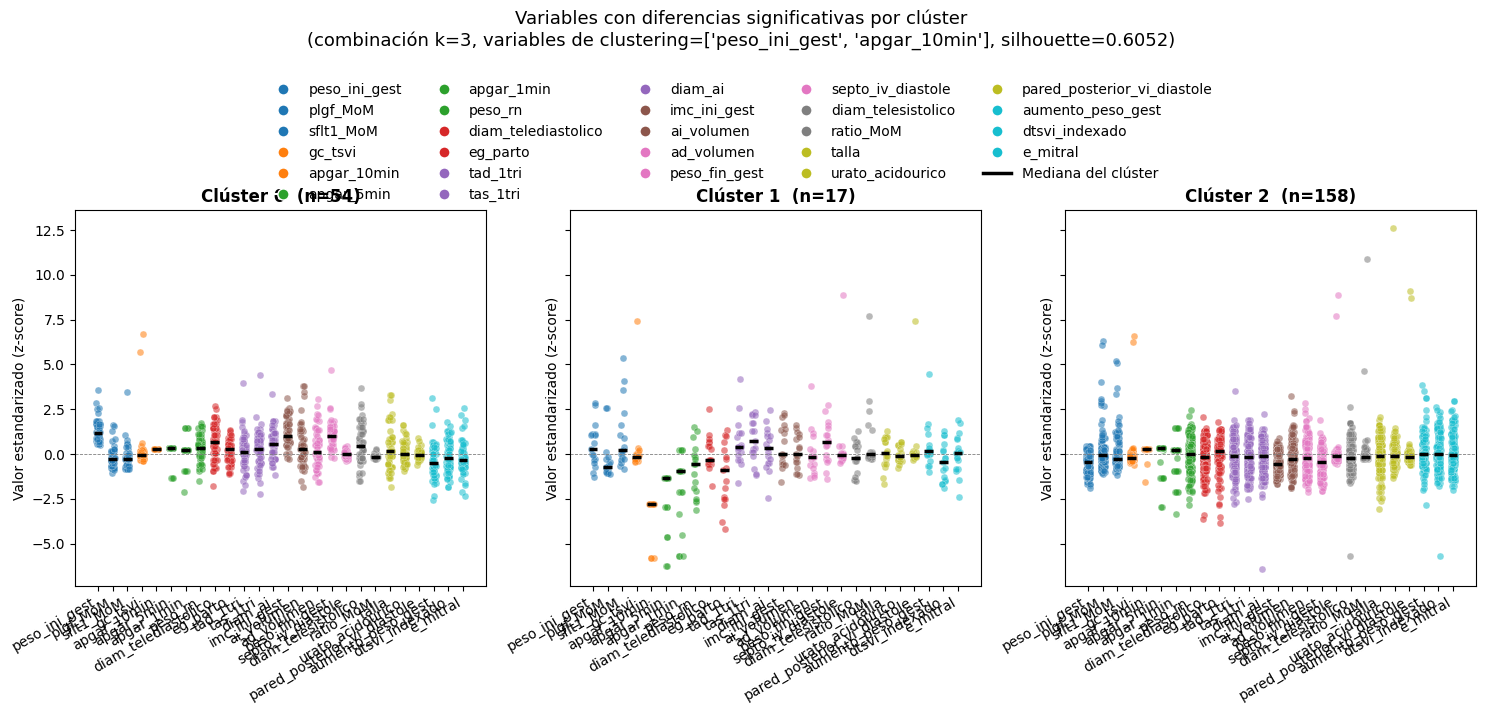

In [55]:
# =========================================================================
# GRÁFICO — VARIABLES SIGNIFICATIVAS POR CLÚSTER (combinación Silhouette = 0.6052)
# Combinación: k=3, variables de clustering = ['peso_ini_gest', 'apgar_10min']
# =========================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- 1. Localizamos la combinación exacta dentro de top_3_results --------
fila_objetivo = top_3_results[np.isclose(top_3_results['silhouette'], 0.6052, atol=1e-4)].iloc[0]
k_actual    = int(fila_objetivo['k'])
vars_actual = fila_objetivo['variables']
sil_score   = fila_objetivo['silhouette']

print(f"Combinación seleccionada -> k={k_actual} | variables={vars_actual} | silhouette={sil_score:.4f}")

# --- 2. Reproducimos el clustering tal y como se hizo en la celda 66 -----
X_cl = df_combi[vars_actual].values
kmeans = KMeans(n_clusters=k_actual, n_init=10, random_state=42)
labels = kmeans.fit_predict(X_cl)

mapa = pd.DataFrame({'id': df_combi['id'].values, 'cluster_temp': labels})
df_desc = pd.merge(df_maestro, mapa, on='id', how='inner')

# --- 3. Calculamos significancia (p-valor) para las variables numéricas --
# Reunimos todas las variables numéricas candidatas (gestación+biomarcadores y eco)
variables_candidatas = [
    v for v in (grupos_informe["GESTACIÓN Y BIOMARCADORES"] + grupos_informe["ECOCARDIOGRAFÍA"])
    if v in df_desc.columns and pd.api.types.is_numeric_dtype(df_desc[v])
]

resultados_p = []
for v in variables_candidatas:
    fila = realizar_analisis_avanzado(df_desc, v, 'cluster_temp')
    resultados_p.append({'variable': fila[0], 'test': fila[1], 'p_valor': float(fila[2])})

df_pvalores = pd.DataFrame(resultados_p).sort_values('p_valor')
print("\nVariables numéricas evaluadas y su p-valor:")
display(df_pvalores)

# Nos quedamos solo con las variables con diferencia significativa (p < 0.05)
vars_significativas = df_pvalores[df_pvalores['p_valor'] < 0.05]['variable'].tolist()
print(f"\nVariables con diferencias significativas (p < 0.05): {vars_significativas}")

if not vars_significativas:
    raise ValueError("Ninguna variable numérica resultó significativa (p < 0.05) para esta combinación.")

# --- 4. Estandarizamos (z-score) cada variable significativa -------------
# Esto es necesario porque las variables están en escalas distintas (peso, apgar, etc.)
# y queremos poder representarlas juntas en el mismo eje Y.
df_plot = df_desc[['cluster_temp'] + vars_significativas].dropna().copy()
for v in vars_significativas:
    df_plot[v] = (df_plot[v] - df_plot[v].mean()) / df_plot[v].std()

# --- 5. Construimos el gráfico: un panel por clúster ----------------------
clusters_ids = sorted(df_plot['cluster_temp'].unique())
n_clusters = len(clusters_ids)

# Un color distinto por variable (consistente entre paneles)
colores = plt.cm.tab10(np.linspace(0, 1, len(vars_significativas)))
color_por_variable = dict(zip(vars_significativas, colores))

fig, axes = plt.subplots(1, n_clusters, figsize=(5 * n_clusters, 6), sharey=True)
if n_clusters == 1:
    axes = [axes]

rng = np.random.default_rng(42)

for ax, c in zip(axes, clusters_ids):
    datos_cluster = df_plot[df_plot['cluster_temp'] == c]

    for i, v in enumerate(vars_significativas):
        valores = datos_cluster[v].values
        # jitter horizontal para que los puntos no se superpongan
        x_jitter = i + rng.uniform(-0.15, 0.15, size=len(valores))

        ax.scatter(x_jitter, valores, color=color_por_variable[v],
                   alpha=0.55, s=25, label=v, edgecolor='white', linewidth=0.3)

        # Raya horizontal marcando la mediana de esa variable en este clúster
        mediana = np.median(valores)
        ax.hlines(mediana, i - 0.3, i + 0.3, colors='black', linewidth=2.5, zorder=5)

    ax.set_title(f"Clúster {c}  (n={len(datos_cluster)})", fontsize=12, fontweight='bold')
    ax.set_xticks(range(len(vars_significativas)))
    ax.set_xticklabels(vars_significativas, rotation=30, ha='right')
    ax.axhline(0, color='gray', linewidth=0.6, linestyle='--')
    ax.set_ylabel("Valor estandarizado (z-score)")

# Leyenda común (variable -> color), evitando duplicados
handles = [plt.Line2D([0], [0], marker='o', color='w', label=v,
                       markerfacecolor=color_por_variable[v], markersize=8)
           for v in vars_significativas]
handles.append(plt.Line2D([0], [0], color='black', linewidth=2.5, label='Mediana del clúster'))

fig.legend(handles=handles, loc='upper center', bbox_to_anchor=(0.5, 1.08),
           ncol=min(len(handles), 5), frameon=False)

fig.suptitle(
    f"Variables con diferencias significativas por clúster\n"
    f"(combinación k={k_actual}, variables de clustering={vars_actual}, silhouette={sil_score:.4f})",
    y=1.18, fontsize=13
)

plt.tight_layout()
plt.show()

Combinación seleccionada -> k=3 | variables=['peso_ini_gest', 'apgar_10min'] | silhouette=0.6052

Variables numéricas evaluadas y su p-valor:


,variable,test,p_valor
0,peso_ini_gest,Kruskal-Wallis,0.0000
16,plgf_MoM,Kruskal-Wallis,0.0000
15,sflt1_MoM,Kruskal-Wallis,0.0000
28,gc_tsvi,Kruskal-Wallis,0.0000
13,apgar_10min,Kruskal-Wallis,0.0000
12,apgar_5min,Kruskal-Wallis,0.0000
11,apgar_1min,Kruskal-Wallis,0.0000
10,peso_rn,Kruskal-Wallis,0.0000
17,diam_telediastolico,Kruskal-Wallis,0.0000
9,eg_parto,Kruskal-Wallis,0.0000



Variables con diferencias significativas (p < 0.05): ['peso_ini_gest', 'plgf_MoM', 'sflt1_MoM', 'gc_tsvi', 'apgar_10min', 'apgar_5min', 'apgar_1min', 'peso_rn', 'diam_telediastolico', 'eg_parto', 'tad_1tri', 'tas_1tri', 'diam_ai', 'imc_ini_gest', 'ai_volumen', 'ad_volumen', 'peso_fin_gest', 'septo_iv_diastole', 'diam_telesistolico', 'ratio_MoM', 'talla', 'urato_acidourico', 'pared_posterior_vi_diastole', 'aumento_peso_gest', 'dtsvi_indexado', 'e_mitral']


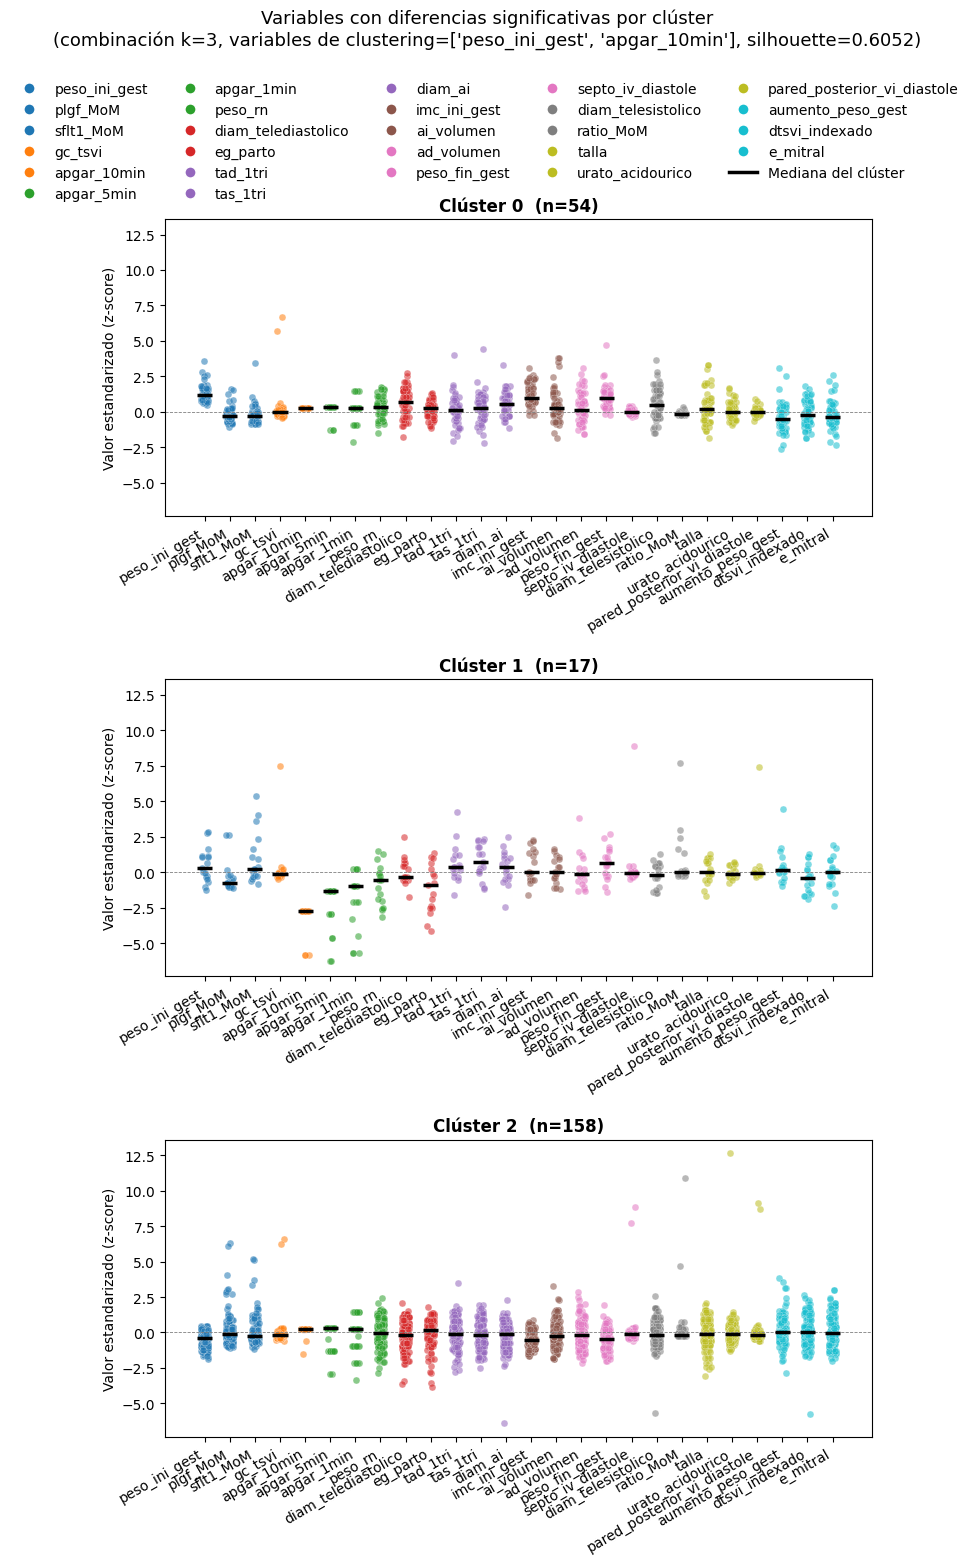

In [56]:
# =========================================================================
# GRÁFICO — VARIABLES SIGNIFICATIVAS POR CLÚSTER (combinación Silhouette = 0.6052)
# Combinación: k=3, variables de clustering = ['peso_ini_gest', 'apgar_10min']
# =========================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- 1. Localizamos la combinación exacta dentro de top_3_results --------
fila_objetivo = top_3_results[np.isclose(top_3_results['silhouette'], 0.6052, atol=1e-4)].iloc[0]
k_actual    = int(fila_objetivo['k'])
vars_actual = fila_objetivo['variables']
sil_score   = fila_objetivo['silhouette']

print(f"Combinación seleccionada -> k={k_actual} | variables={vars_actual} | silhouette={sil_score:.4f}")

# --- 2. Reproducimos el clustering tal y como se hizo en la celda 66 -----
X_cl = df_combi[vars_actual].values
kmeans = KMeans(n_clusters=k_actual, n_init=10, random_state=42)
labels = kmeans.fit_predict(X_cl)

mapa = pd.DataFrame({'id': df_combi['id'].values, 'cluster_temp': labels})
df_desc = pd.merge(df_maestro, mapa, on='id', how='inner')

# --- 3. Calculamos significancia (p-valor) para las variables numéricas --
# Reunimos todas las variables numéricas candidatas (gestación+biomarcadores y eco)
variables_candidatas = [
    v for v in (grupos_informe["GESTACIÓN Y BIOMARCADORES"] + grupos_informe["ECOCARDIOGRAFÍA"])
    if v in df_desc.columns and pd.api.types.is_numeric_dtype(df_desc[v])
]

resultados_p = []
for v in variables_candidatas:
    fila = realizar_analisis_avanzado(df_desc, v, 'cluster_temp')
    resultados_p.append({'variable': fila[0], 'test': fila[1], 'p_valor': float(fila[2])})

df_pvalores = pd.DataFrame(resultados_p).sort_values('p_valor')
print("\nVariables numéricas evaluadas y su p-valor:")
display(df_pvalores)

# Nos quedamos solo con las variables con diferencia significativa (p < 0.05)
vars_significativas = df_pvalores[df_pvalores['p_valor'] < 0.05]['variable'].tolist()
print(f"\nVariables con diferencias significativas (p < 0.05): {vars_significativas}")

if not vars_significativas:
    raise ValueError("Ninguna variable numérica resultó significativa (p < 0.05) para esta combinación.")

# --- 4. Estandarizamos (z-score) cada variable significativa -------------
# Esto es necesario porque las variables están en escalas distintas (peso, apgar, etc.)
# y queremos poder representarlas juntas en el mismo eje Y.
df_plot = df_desc[['cluster_temp'] + vars_significativas].dropna().copy()
for v in vars_significativas:
    df_plot[v] = (df_plot[v] - df_plot[v].mean()) / df_plot[v].std()

# --- 5. Construimos el gráfico: un panel por clúster ----------------------
clusters_ids = sorted(df_plot['cluster_temp'].unique())
n_clusters = len(clusters_ids)

# Un color distinto por variable (consistente entre paneles)
colores = plt.cm.tab10(np.linspace(0, 1, len(vars_significativas)))
color_por_variable = dict(zip(vars_significativas, colores))

fig, axes = plt.subplots(n_clusters, 1, figsize=(8, 5 * n_clusters), sharey=True)
if n_clusters == 1:
    axes = [axes]

rng = np.random.default_rng(42)

for ax, c in zip(axes, clusters_ids):
    datos_cluster = df_plot[df_plot['cluster_temp'] == c]

    for i, v in enumerate(vars_significativas):
        valores = datos_cluster[v].values
        # jitter horizontal para que los puntos no se superpongan
        x_jitter = i + rng.uniform(-0.15, 0.15, size=len(valores))

        ax.scatter(x_jitter, valores, color=color_por_variable[v],
                   alpha=0.55, s=25, label=v, edgecolor='white', linewidth=0.3)

        # Raya horizontal marcando la mediana de esa variable en este clúster
        mediana = np.median(valores)
        ax.hlines(mediana, i - 0.3, i + 0.3, colors='black', linewidth=2.5, zorder=5)

    ax.set_title(f"Clúster {c}  (n={len(datos_cluster)})", fontsize=12, fontweight='bold')
    ax.set_xticks(range(len(vars_significativas)))
    ax.set_xticklabels(vars_significativas, rotation=30, ha='right')
    ax.axhline(0, color='gray', linewidth=0.6, linestyle='--')
    ax.set_ylabel("Valor estandarizado (z-score)")

# Leyenda común (variable -> color), evitando duplicados
handles = [plt.Line2D([0], [0], marker='o', color='w', label=v,
                       markerfacecolor=color_por_variable[v], markersize=8)
           for v in vars_significativas]
handles.append(plt.Line2D([0], [0], color='black', linewidth=2.5, label='Mediana del clúster'))

fig.legend(handles=handles, loc='upper center', bbox_to_anchor=(0.5, 1.0),
           ncol=min(len(handles), 5), frameon=False, fontsize=10)

fig.suptitle(
    f"Variables con diferencias significativas por clúster\n"
    f"(combinación k={k_actual}, variables de clustering={vars_actual}, silhouette={sil_score:.4f})",
    y=1.04, fontsize=13
)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.subplots_adjust(top=0.90, hspace=0.55)
plt.show()

Combinación seleccionada -> k=3 | variables=['peso_ini_gest', 'apgar_10min'] | silhouette=0.6052

Variables numéricas evaluadas y su p-valor:


,variable,test,p_valor
0,peso_ini_gest,Kruskal-Wallis,0.0000
16,plgf_MoM,Kruskal-Wallis,0.0000
15,sflt1_MoM,Kruskal-Wallis,0.0000
28,gc_tsvi,Kruskal-Wallis,0.0000
13,apgar_10min,Kruskal-Wallis,0.0000
12,apgar_5min,Kruskal-Wallis,0.0000
11,apgar_1min,Kruskal-Wallis,0.0000
10,peso_rn,Kruskal-Wallis,0.0000
17,diam_telediastolico,Kruskal-Wallis,0.0000
9,eg_parto,Kruskal-Wallis,0.0000



Variables con diferencias significativas (p < 0.05): ['peso_ini_gest', 'plgf_MoM', 'sflt1_MoM', 'gc_tsvi', 'apgar_10min', 'apgar_5min', 'apgar_1min', 'peso_rn', 'diam_telediastolico', 'eg_parto', 'tad_1tri', 'tas_1tri', 'diam_ai', 'imc_ini_gest', 'ai_volumen', 'ad_volumen', 'peso_fin_gest', 'septo_iv_diastole', 'diam_telesistolico', 'ratio_MoM', 'talla', 'urato_acidourico', 'pared_posterior_vi_diastole', 'aumento_peso_gest', 'dtsvi_indexado', 'e_mitral']


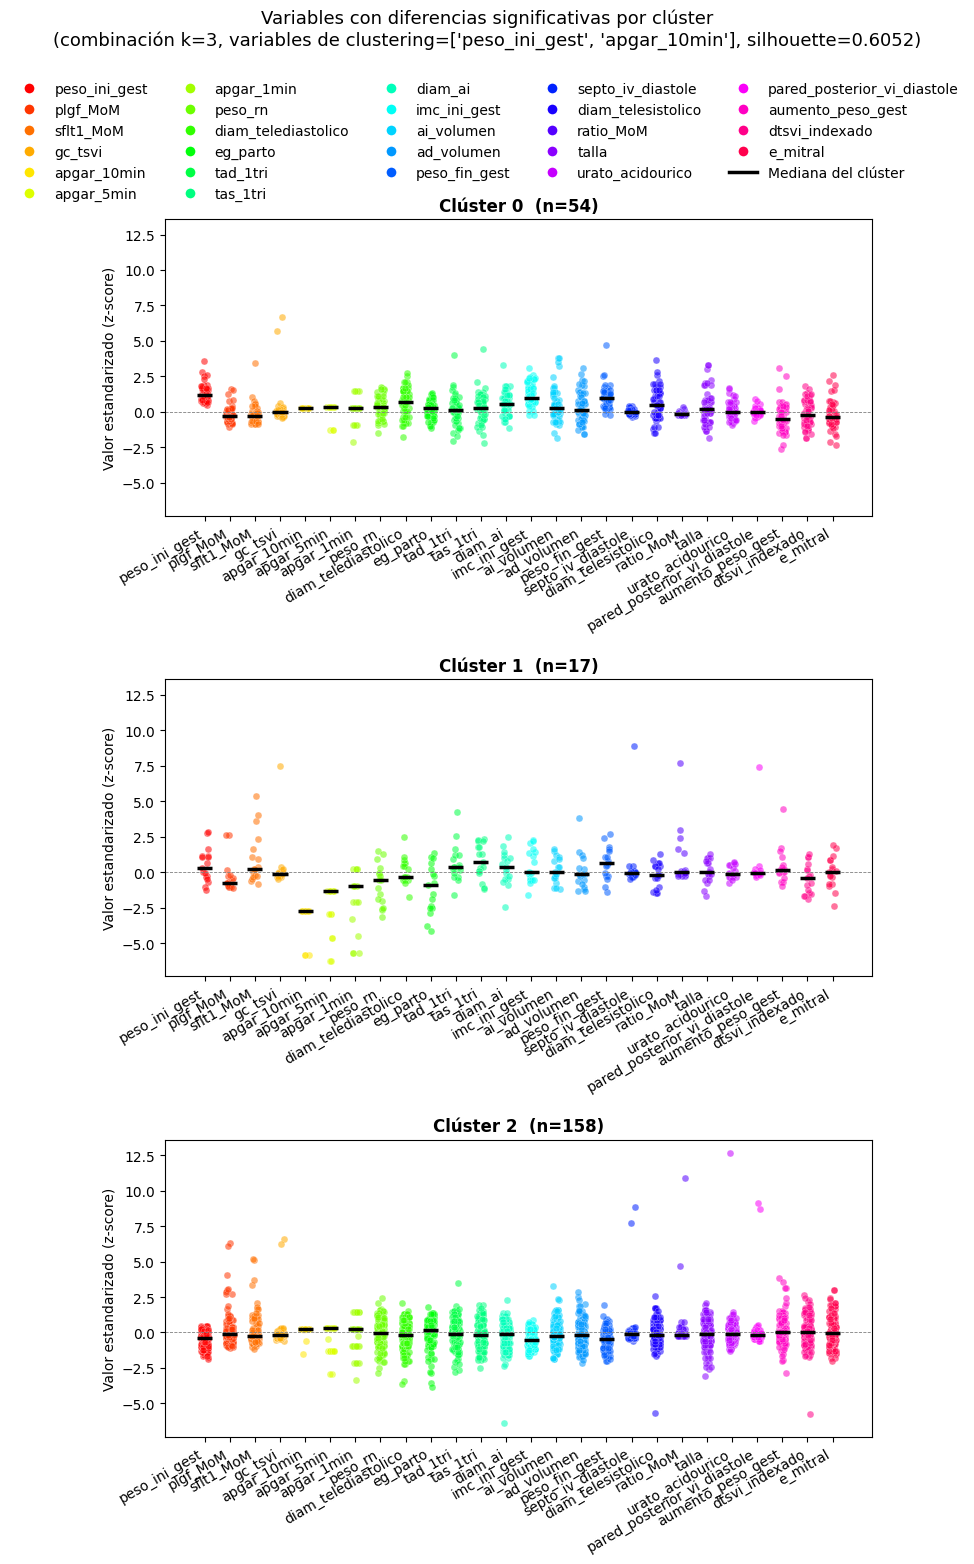

In [57]:
# =========================================================================
# GRÁFICO — VARIABLES SIGNIFICATIVAS POR CLÚSTER (combinación Silhouette = 0.6052)
# Combinación: k=3, variables de clustering = ['peso_ini_gest', 'apgar_10min']
# =========================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- 1. Localizamos la combinación exacta dentro de top_3_results --------
fila_objetivo = top_3_results[np.isclose(top_3_results['silhouette'], 0.6052, atol=1e-4)].iloc[0]
k_actual    = int(fila_objetivo['k'])
vars_actual = fila_objetivo['variables']
sil_score   = fila_objetivo['silhouette']

print(f"Combinación seleccionada -> k={k_actual} | variables={vars_actual} | silhouette={sil_score:.4f}")

# --- 2. Reproducimos el clustering tal y como se hizo en la celda 66 -----
X_cl = df_combi[vars_actual].values
kmeans = KMeans(n_clusters=k_actual, n_init=10, random_state=42)
labels = kmeans.fit_predict(X_cl)

mapa = pd.DataFrame({'id': df_combi['id'].values, 'cluster_temp': labels})
df_desc = pd.merge(df_maestro, mapa, on='id', how='inner')

# --- 3. Calculamos significancia (p-valor) para las variables numéricas --
# Reunimos todas las variables numéricas candidatas (gestación+biomarcadores y eco)
variables_candidatas = [
    v for v in (grupos_informe["GESTACIÓN Y BIOMARCADORES"] + grupos_informe["ECOCARDIOGRAFÍA"])
    if v in df_desc.columns and pd.api.types.is_numeric_dtype(df_desc[v])
]

resultados_p = []
for v in variables_candidatas:
    fila = realizar_analisis_avanzado(df_desc, v, 'cluster_temp')
    resultados_p.append({'variable': fila[0], 'test': fila[1], 'p_valor': float(fila[2])})

df_pvalores = pd.DataFrame(resultados_p).sort_values('p_valor')
print("\nVariables numéricas evaluadas y su p-valor:")
display(df_pvalores)

# Nos quedamos solo con las variables con diferencia significativa (p < 0.05)
vars_significativas = df_pvalores[df_pvalores['p_valor'] < 0.05]['variable'].tolist()
print(f"\nVariables con diferencias significativas (p < 0.05): {vars_significativas}")

if not vars_significativas:
    raise ValueError("Ninguna variable numérica resultó significativa (p < 0.05) para esta combinación.")

# --- 4. Estandarizamos (z-score) cada variable significativa -------------
# Esto es necesario porque las variables están en escalas distintas (peso, apgar, etc.)
# y queremos poder representarlas juntas en el mismo eje Y.
df_plot = df_desc[['cluster_temp'] + vars_significativas].dropna().copy()
for v in vars_significativas:
    df_plot[v] = (df_plot[v] - df_plot[v].mean()) / df_plot[v].std()

# --- 5. Construimos el gráfico: un panel por clúster ----------------------
clusters_ids = sorted(df_plot['cluster_temp'].unique())
n_clusters = len(clusters_ids)

# Paleta con tantos colores distintos como variables significativas haya
# (tab10 solo tiene 10 colores -> si hay más variables, usamos tab20 o,
# si aún no bastan, generamos colores recorriendo el círculo HSV)
n_vars = len(vars_significativas)
if n_vars <= 10:
    cmap = plt.cm.get_cmap('tab10')
    colores = [cmap(i) for i in range(n_vars)]
elif n_vars <= 20:
    cmap = plt.cm.get_cmap('tab20')
    colores = [cmap(i) for i in range(n_vars)]
else:
    colores = plt.cm.hsv(np.linspace(0, 1, n_vars, endpoint=False))

color_por_variable = dict(zip(vars_significativas, colores))

fig, axes = plt.subplots(n_clusters, 1, figsize=(8, 5 * n_clusters), sharey=True)
if n_clusters == 1:
    axes = [axes]

rng = np.random.default_rng(42)

for ax, c in zip(axes, clusters_ids):
    datos_cluster = df_plot[df_plot['cluster_temp'] == c]

    for i, v in enumerate(vars_significativas):
        valores = datos_cluster[v].values
        # jitter horizontal para que los puntos no se superpongan
        x_jitter = i + rng.uniform(-0.15, 0.15, size=len(valores))

        ax.scatter(x_jitter, valores, color=color_por_variable[v],
                   alpha=0.55, s=25, label=v, edgecolor='white', linewidth=0.3)

        # Raya horizontal marcando la mediana de esa variable en este clúster
        mediana = np.median(valores)
        ax.hlines(mediana, i - 0.3, i + 0.3, colors='black', linewidth=2.5, zorder=5)

    ax.set_title(f"Clúster {c}  (n={len(datos_cluster)})", fontsize=12, fontweight='bold')
    ax.set_xticks(range(len(vars_significativas)))
    ax.set_xticklabels(vars_significativas, rotation=30, ha='right')
    ax.axhline(0, color='gray', linewidth=0.6, linestyle='--')
    ax.set_ylabel("Valor estandarizado (z-score)")

# Leyenda común (variable -> color), evitando duplicados
handles = [plt.Line2D([0], [0], marker='o', color='w', label=v,
                       markerfacecolor=color_por_variable[v], markersize=8)
           for v in vars_significativas]
handles.append(plt.Line2D([0], [0], color='black', linewidth=2.5, label='Mediana del clúster'))

fig.legend(handles=handles, loc='upper center', bbox_to_anchor=(0.5, 1.0),
           ncol=min(len(handles), 5), frameon=False, fontsize=10)

fig.suptitle(
    f"Variables con diferencias significativas por clúster\n"
    f"(combinación k={k_actual}, variables de clustering={vars_actual}, silhouette={sil_score:.4f})",
    y=1.04, fontsize=13
)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.subplots_adjust(top=0.90, hspace=0.55)
plt.show()